# Extract features

region Counts:
North: 2857
Central: 2777
South: 2444


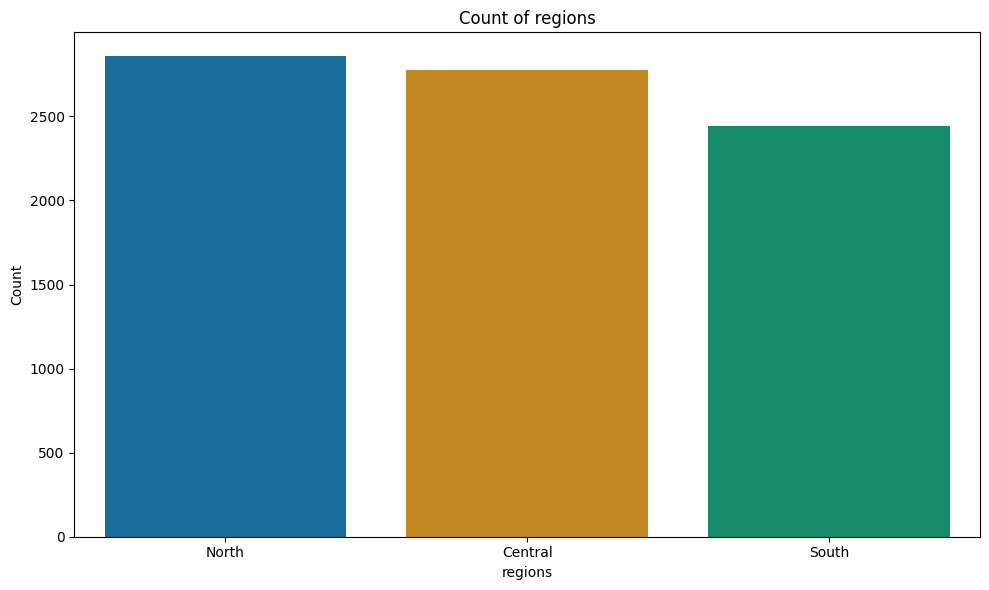

In [2]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Đường dẫn tới thư mục chứa tập dữ liệu
# Các thư mục cần quét
base_path = "/kaggle/input/vietnamese-accent-3-regions"
folders = ["South", "Central", "North"]

# Mapping mã số vùng -> tên vùng
region_map = {
    '1': 'North',
    '2': 'Central',
    '3': 'South',
}

# Extract region labels from filenames
filenames = []
for folder in folders:
    path = os.path.join(base_path, folder, "**", "*.wav")
    filenames.extend(glob.glob(path, recursive=True))
regions = [region_map[os.path.basename(f).split('-')[0]] for f in filenames if os.path.basename(f).split('-')[0] in region_map]

# Count occurrences of each region
region_counts = Counter(regions)

# Sort regions by predefined order
region_order = ['North', 'Central', 'South']
counts = [region_counts[r] for r in region_order if r in region_counts]

# Print the count of each region
print("region Counts:")
for region in region_order:
    count = region_counts.get(region, 0)
    print(f"{region}: {count}")

# Plot the region distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=pd.Series(region_order), y=counts, palette="colorblind")
plt.xlabel("regions")
plt.ylabel("Count")
plt.title("Count of regions")
plt.tight_layout()
plt.show()

region Counts:
Male: 4911
Female: 3167


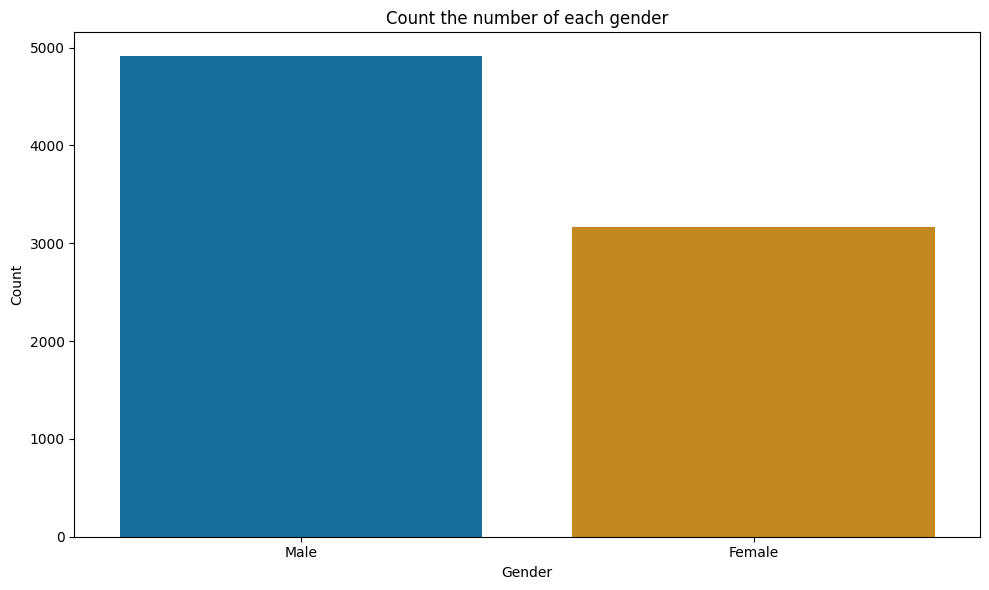

In [3]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Đường dẫn tới thư mục chứa tập dữ liệu
# Các thư mục cần quét
path = "/kaggle/input/vietnamese-accent-3-regions/***/**/*.wav"
folders = ["South", "Central", "North"]

# Mapping RAVDESS numeric encoding to regions
Gender_map = {
    '0': 'Male',
    '1': 'Female'
}

# Extract region labels from filenames
filenames = []
for folder in folders:
    path = os.path.join(base_path, folder, "**", "*.wav")
    filenames.extend(glob.glob(path, recursive=True))
genders = [Gender_map[os.path.basename(f).split('-')[2]] for f in filenames if os.path.basename(f).split('-')[2] in Gender_map]

# Count occurrences of each region
genders_counts = Counter(genders)

# Sort regions by predefined order
Gender_order = ['Male','Female']
counts = [genders_counts[g] for g in Gender_order if g in genders_counts]

# Print the count of each region
print("region Counts:")
for g in Gender_order:
    count = genders_counts.get(g, 0)
    print(f"{g}: {count}")

# Plot the region distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=pd.Series(Gender_order), y=counts, palette="colorblind")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Count the number of each gender")
plt.tight_layout()
plt.show()

Region_Gender Counts:
North_Male: 2128
North_Female: 729
Central_Male: 1452
Central_Female: 1325
South_Male: 1331
South_Female: 1113


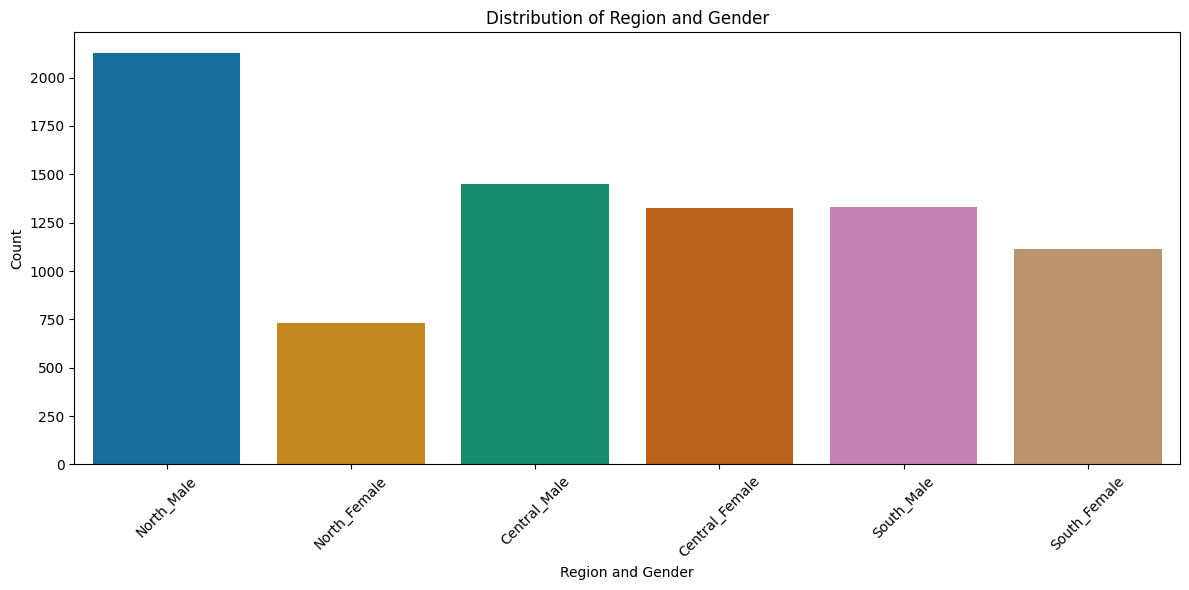

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Đường dẫn tới thư mục chứa tập dữ liệu
# Các thư mục cần quét
path = "/kaggle/input/vietnamese-accent-3-regions/***/**/*.wav"
folders = ["South", "Central", "North"]

# Mapping RAVDESS numeric encoding to regions và gender
region_map = {
    '1': 'North',
    '2': 'Central',
    '3': 'South',
}
gender_map = {
    '0': 'Male',
    '1': 'Female',
}

# Trích xuất region và gender từ tên file
filenames = []
for folder in folders:
    path = os.path.join(base_path, folder, "**", "*.wav")
    filenames.extend(glob.glob(path, recursive=True))
region_gender_list = []
for f in filenames:
    basename = os.path.basename(f)
    parts = basename.split('-')
    if len(parts) >= 2 and parts[0] in region_map:
        region = region_map[parts[0]]  # Lấy region từ phần đầu tiên
        # Giả sử gender nằm ở phần thứ hai của tên file (điều chỉnh nếu khác)
        gender = gender_map.get(parts[2], 'Unknown')  # Lấy gender (nếu có)
        region_gender = f"{region}_{gender}"
        region_gender_list.append(region_gender)

# Đếm số lượng từng tổ hợp region_gender
region_gender_counts = Counter(region_gender_list)

# Tạo danh sách tổ hợp theo thứ tự mong muốn
region_gender_order = [
    'North_Male', 'North_Female',
    'Central_Male', 'Central_Female',
    'South_Male', 'South_Female'
]
counts = [region_gender_counts.get(rg, 0) for rg in region_gender_order]

# In số lượng từng tổ hợp
print("Region_Gender Counts:")
for rg in region_gender_order:
    count = region_gender_counts.get(rg, 0)
    print(f"{rg}: {count}")

# Tạo DataFrame để visualize
data = pd.DataFrame({
    'Region_Gender': region_gender_order,
    'Count': counts
})

# Plot phân bố region_gender
plt.figure(figsize=(12, 6))
sns.barplot(x='Region_Gender', y='Count', data=data, palette="colorblind")
plt.xlabel("Region and Gender")
plt.ylabel("Count")
plt.title("Distribution of Region and Gender")
plt.xticks(rotation=45)  # Xoay nhãn để dễ đọc
plt.tight_layout()
plt.show()

In [69]:
# Hàm chuẩn hóa độ dài âm thanh
def pad_or_trim_audio(data, sr, target_length=3):
    target_samples = int(sr * target_length)
    current_length = len(data)

    if current_length < target_samples:  # Nếu ngắn hơn, chèn thêm 0 (padding)
        pad_width = target_samples - current_length
        data = np.pad(data, (0, pad_width), mode='constant')
    else:  # Nếu dài hơn, cắt bớt (trimming)
        data = data[:target_samples]

    return data
    
def match_loudness(audio, target_rms = 0.015823712572455406):
    current_rms = np.sqrt(np.mean(audio**2))
    if current_rms == 0:
        return audio
    scalar = target_rms / current_rms
    return audio * scalar
    
# Hàm chuẩn hóa âm thanh
def normalize_audio(data):
    return librosa.util.normalize(data)

# Hàm trích xuất đặc trưng
def extract_features(data, sampling_rate, n_mfcc=40):
    mfccs = librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=n_mfcc).mean(axis=1)
    chroma = librosa.feature.chroma_stft(y=data, sr=sampling_rate).mean(axis=1)
    spectral_centroid = librosa.feature.spectral_centroid(y=data, sr=sampling_rate).mean()
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=data, sr=sampling_rate).mean()
    return np.hstack((mfccs, chroma, [spectral_centroid], [spectral_bandwidth]))

In [ ]:
from multiprocessing import Pool, cpu_count

# Hàm xử lý 1 file
def process_file(file_path):
    try:
        data, sampling_rate = librosa.load(file_path, sr=48000)
        data = match_loudness(data)
        data = normalize_audio(data)
        data = pad_or_trim_audio(data, sampling_rate)

        features = extract_features(data, sampling_rate)

        filename = os.path.basename(file_path)
        label_region = filename.split("-")[0]
        label_gender = filename.split("-")[2]

        return (file_path, features, label_region, label_gender)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Danh sách thư mục được duyệt
allowed_folders = ["South", "Central", "North"]
base_path = "/kaggle/input/vietnamese-accent-3-regions"

# Lấy danh sách file .wav chỉ từ các folder cho phép
file_list = []
for root, dirs, files in os.walk(base_path):
    # Lấy tên thư mục cha (mức đầu tiên sau base_path)
    parts = root.split(os.sep)
    if len(parts) > 5:  # đảm bảo có phần sau base_path
        folder_name = parts[4]  # ví dụ: base_path/.../South
        if folder_name in allowed_folders:
            for filename in files:
                if filename.endswith(".wav"):
                    file_list.append(os.path.join(root, filename))

print(f"Found {len(file_list)} audio files from allowed folders.")

# Dùng multiprocessing
num_workers = max(1, cpu_count() - 1)  # Giữ lại 1 CPU cho hệ thống
with Pool(num_workers) as pool:
    results = pool.map(process_file, file_list)

# Lọc kết quả hợp lệ
results = [r for r in results if r is not None]

# Tách dữ liệu ra DataFrame
X_path = [r[0] for r in results]
X = [r[1] for r in results]
y_region = [r[2] for r in results]
y_gender = [r[3] for r in results]
print(set(len(f) for f in X))
feature_names = [f"mfcc_{i}" for i in range(40)] + \
                [f"chroma_{i}" for i in range(12)] + \
                ["spectral_centroid", "spectral_bandwidth"]

features_df = pd.DataFrame(X_path, columns=['path'])
features_df[feature_names] = X
features_df['region'] = y_region
features_df['gender'] = y_gender

# Lưu CSV
features_df.to_csv("SRR_SGR_Dataset.csv", index=False)
print("✅ Feature extraction completed with multiprocessing and saved to SRR_SGR_Dataset.csv.")

In [ ]:
from multiprocessing import Pool, cpu_count

# Hàm xử lý 1 file
def process_file(file_path):
    try:
        data, sampling_rate = librosa.load(file_path, sr=48000)
        data = match_loudness(data)
        data = normalize_audio(data)
        data = pad_or_trim_audio(data, sampling_rate)

        features = extract_features(data, sampling_rate)

        filename = os.path.basename(file_path)
        label_region = filename.split("-")[0]
        label_gender = filename.split("-")[2]

        return (file_path, features, label_region, label_gender)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Danh sách thư mục được duyệt
allowed_folders = ["/kaggle/input/vietnamese-accent-3-regions/South", "/kaggle/input/vietnamese-accent-3-regions/Central", "/kaggle/input/vietnamese-accent-3-regions/North"]


# Lấy danh sách file .wav chỉ từ các folder cho phép
file_list = []
for base_path in allowed_folders: 
    for root, dirs, files in os.walk(base_path):
        for filename in files:
            if filename.endswith(".wav"):
                    file_list.append(os.path.join(root, filename))

print(f"Found {len(file_list)} audio files from allowed folders.")

# Dùng multiprocessing
num_workers = max(1, cpu_count() - 1)  # Giữ lại 1 CPU cho hệ thống
with Pool(num_workers) as pool:
    results = pool.map(process_file, file_list)

# Lọc kết quả hợp lệ
results = [r for r in results if r is not None]

# Tách dữ liệu ra DataFrame
X_path = [r[0] for r in results]
X = [r[1] for r in results]
y_region = [r[2] for r in results]
y_gender = [r[3] for r in results]
print(set(len(f) for f in X))
feature_names = [f"mfcc_{i}" for i in range(40)] + \
                [f"chroma_{i}" for i in range(12)] + \
                ["spectral_centroid", "spectral_bandwidth"]

features_df = pd.DataFrame(X_path, columns=['path'])
features_df[feature_names] = X
features_df['region'] = y_region
features_df['gender'] = y_gender

# Lưu CSV
features_df.to_csv("SRR_SGR_Dataset.csv", index=False)
print("✅ Feature extraction completed with multiprocessing and saved to SRR_SGR_Dataset.csv.")

In [6]:
# Thư mục chứa file âm thanh
# Danh sách thư mục được duyệt
allowed_folders = ["/kaggle/input/vietnamese-accent-3-regions/South", "/kaggle/input/vietnamese-accent-3-regions/Central", "/kaggle/input/vietnamese-accent-3-regions/North"]


# Dữ liệu huấn luyện
X_path = []
X = []  # input
y_region = []  # label
y_gender = []
# Duyệt qua tất cả các file trong thư mục
for audio_folder in allowed_folders:
    for root, dirs, files in os.walk(audio_folder):
        for filename in files:
            if filename.endswith(".wav"):
                file_path = os.path.join(root, filename)
                
                # Tải âm thanh
                data, sampling_rate = librosa.load(file_path, sr=48000)
                data = match_loudness(data)
                data = normalize_audio(data)
                
                # Trích xuất đặc trưng
                features = extract_features(data, sampling_rate)
                
                # Lấy nhãn từ tên file (số thứ 3 trong tên file)
                label_region = filename.split("-")[0]  # Lấy phần tử thứ 3 (index 2)
                label_gender = filename.split("-")[2]
                # Chọn mẫu đầu tiên để in ra biểu đồ 
                # Lưu vào danh sách
                X.append(features)
                y_region.append(label_region)
                y_gender.append(label_gender)
                X_path.append(file_path)
# Chuyển X thành DataFrame
feature_names = [f"mfcc_{i}" for i in range(40)] + \
                [f"chroma_{i}" for i in range(12)] + \
                ["spectral_centroid", "spectral_bandwidth"]
features_df = pd.DataFrame(X_path, columns=['path'])
features_df[feature_names] = X
features_df['region'] = y_region
features_df['gender'] = y_gender

# Lưu thành CSV
features_df.to_csv("SRR_SGR_Dataset.csv", index=False)
print("✅ Feature extraction completed and saved to audio_features.csv.")

✅ Feature extraction completed and saved to audio_features.csv.


# Split Dataset

In [138]:
import pandas as pd

# Đọc dữ liệu
file_path = '/kaggle/input/srr-sgrfix/SRR_SGR_Dataset.csv'  # Thay bằng đường dẫn file của bạn
df = pd.read_csv(file_path)
speaker_val = [
    'Se chỉ luồn kim. NSND Lê Dung - Người hát dân ca hay nhất - Thi Âm nhạc Quốc tế Tchaikovsky lần 7',
    'Trống Cơm - Thương Huyền _Thu thanh trước 1975_ _ Official Lyric Video by Hà Nội Vi Vu',
    'Lý cây đa - Kim Oanh - Dân Ca Quan Họ Bắc Ninh',
    'Ca Trù Hồng Hồng Tuyết Tuyết - Kim Luyến _Official_',
    'Hội anh em hài miền Bắc thi ca nhớ về QUÊ NHÀ _ Gặp nhau cuối tuần _ Phim hài VTV hay',

    'Ca Huế_ Tương Tư Khúc - Dạ Lê',
    'NGHỀ RÈN Ở HUẾ',
    'Huế Xưa - Ngô Quốc Linh',
    'Người Huế trong nhịp sống hiện đại',

    'An Giang 2024 - Những sự kiện nổi bật _ Đài Truyền hình An Giang',
    'Dạ cổ hoài lang - Bích Phượng ca _ Đờn ca tài tử _Vietnamese traditional music',
    'Mười Thương Làng Xóm Quê Mình _Theo Điệu Nói Thơ Bạc Liêu_ - Bích Phượng ca',
    'LÝ KÉO CHÀI - Huybothai x Cao Bá Hưng _ OST Thỏ Bảy Màu và Chiến Tranh Cầu Cá _ Lyric Video',
    'Tháng Năm Không Quên - H2K x KN _OFFICIAL MV_  _ RV Underground',
    'Hành Lang Cũ _Hạ Nhớ_ - Long Nón Lá x Masew',
    'CON TRAI CƯNG _Piano Version_ _ ICM x B Ray _ MV Official',
    'Đồi Thông Hai Mộ - Phương Anh _ Official MV'
]

speaker_test = [
    'BÈO DẠT MÂY TRÔI x CÒ LẢ x TRỐNG CƠM _ Tốp ca nam nhà hát dân ca QHBN _ La Cà Hát Ca _9',
    'Bản Tin Thời Sự Trưa 8_3 _ Cập Nhật Tin Tức Mới Nhất Trong Ngày _ BTVv',
    
    'Lý Ngựa Ô Huế _Ly horse umbrella Hue_ - Quang Linh',
    'CREATIVE TOURISM - Nhịp cầu tuổi trẻ',
    'Chuyện Huế_ Miền gái đẹp Kim Long',
    'Ca Huế_  Tứ Đại Cảnh - lời cổ -  NS Kim Liên',
    
    'Dự báo thời tiết Tiền Giang ngày 31.03.2023 _ THTG',
    'Dự báo thời tiết_ Sài Gòn và cả Nam Bộ bước vào mùa nắng nóng nhất trong năm',
    'ÁO SỜN VAI _ Hồ Khắc Tùng _ St_Đậm Nguyễn_ Người có còn thương thương dùm tôi manh áo dãi dầu…',
    'BTV Việt Phong nói giọng miền Nam - Tin tức 14h trên kênh VTV1 _10_2015_',
    'Nóng Sài Gòn_ Thông tin mới liên quan vụ án Trương Mỹ Lan_ Báo Lao Động',
    'Duyên Phận _ Dương Hồng Loan',
    'Dự báo thời tiết TP. Cần Thơ sáng 19_2_2025 _ THTPCT'
]

train_df = df[df['path'].apply(lambda x: (x.split('/')[5] not in speaker_val) and (x.split('/')[5] not in speaker_test))]
val_df = df[df['path'].apply(lambda x: x.split('/')[5] in speaker_val)]
test_df = df[df['path'].apply(lambda x: x.split('/')[5] in speaker_test)]

print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

val_df

Train set: 5396 samples
Validation set: 1402 samples
Test set: 1280 samples


,path,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,spectral_centroid,spectral_bandwidth,region,gender
0,/kaggle/input/vietnamese-accent-3-regions/Sout...,-207.112000,180.037262,-32.913868,8.554792,-21.580719,7.494885,-39.150383,-14.809875,-3.859048,...,0.294655,0.468816,0.287661,0.224445,0.168378,0.193240,1936.676769,2448.537998,3,0
1,/kaggle/input/vietnamese-accent-3-regions/Sout...,-217.140213,192.330063,-23.985096,21.253824,-10.211488,14.138489,-37.951958,-1.102234,0.160209,...,0.229932,0.275531,0.271698,0.256176,0.214536,0.286841,1785.866897,2454.515414,3,0
2,/kaggle/input/vietnamese-accent-3-regions/Sout...,-163.862732,162.371048,-37.279655,5.697883,-32.076942,-0.697105,-35.433731,-13.842777,-19.677620,...,0.399632,0.426541,0.172838,0.226480,0.171647,0.116333,2047.438058,2687.194943,3,0
3,/kaggle/input/vietnamese-accent-3-regions/Sout...,-166.618347,176.613205,-25.207602,14.637269,-1.562232,22.735262,-21.847214,-8.967909,10.421224,...,0.309197,0.364844,0.297315,0.406318,0.310883,0.356304,1866.266117,2443.369543,3,0
4,/kaggle/input/vietnamese-accent-3-regions/Sout...,-227.790665,176.920502,-16.900354,19.142015,-17.465368,13.331717,-44.953644,-17.936777,0.672823,...,0.135964,0.190921,0.272949,0.398631,0.345803,0.288019,1965.501407,2651.288981,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8073,/kaggle/input/vietnamese-accent-3-regions/Nort...,-136.613647,192.616730,-79.384743,12.325231,-22.799309,14.564578,3.427322,5.258252,4.212190,...,0.426163,0.446408,0.175574,0.246251,0.459365,0.318294,2051.623883,1982.175999,1,1
8074,/kaggle/input/vietnamese-accent-3-regions/Nort...,-132.356903,196.376907,-57.480366,28.020945,-26.762550,19.898598,-4.626067,8.805502,12.099164,...,0.445600,0.460280,0.203876,0.139890,0.181953,0.184949,2007.771808,2286.908889,1,1
8075,/kaggle/input/vietnamese-accent-3-regions/Nort...,-148.505310,195.343246,-60.162880,29.890757,-27.723186,10.235357,-4.508979,0.627155,9.884723,...,0.303585,0.672577,0.402331,0.183561,0.258468,0.234292,1986.813221,2228.139711,1,1
8076,/kaggle/input/vietnamese-accent-3-regions/Nort...,-153.395966,186.328522,-73.840988,38.306541,-0.504338,13.238521,-16.491610,-1.166970,15.577554,...,0.392240,0.435598,0.283934,0.344569,0.502393,0.345762,2134.694175,2178.298300,1,1


In [129]:
train_df

,path,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,spectral_centroid,spectral_bandwidth,region,gender
21,/kaggle/input/vietnamese-accent-3-regions/Sout...,-75.101105,148.160919,-36.776859,35.486156,-29.000929,33.574413,-22.327845,13.409608,-2.947440,...,0.576145,0.625256,0.605798,0.612515,0.617396,0.430451,2983.229927,3589.711849,3,0
22,/kaggle/input/vietnamese-accent-3-regions/Sout...,-86.262215,156.805405,-26.236675,36.544659,-26.370419,29.838854,-14.016427,18.590473,1.318130,...,0.512660,0.465952,0.418094,0.456425,0.363747,0.353689,2662.630931,3446.128421,3,0
23,/kaggle/input/vietnamese-accent-3-regions/Sout...,-84.371567,146.000519,-15.496277,58.226238,-25.953979,39.482304,-12.788487,20.100708,-1.486911,...,0.503064,0.491309,0.457843,0.553765,0.531836,0.560150,3039.243146,3823.735202,3,0
24,/kaggle/input/vietnamese-accent-3-regions/Sout...,-105.043823,154.373581,-37.458809,46.377895,-32.873955,33.013790,-19.950689,13.539744,1.195830,...,0.337518,0.390666,0.380289,0.368055,0.285500,0.420391,2998.442861,3434.936127,3,0
25,/kaggle/input/vietnamese-accent-3-regions/Sout...,-118.309456,160.194855,-30.815145,37.697193,-28.699436,32.654755,-22.701136,16.834171,1.401205,...,0.342608,0.370943,0.348920,0.396078,0.314930,0.347819,2686.120659,3421.618854,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8010,/kaggle/input/vietnamese-accent-3-regions/Nort...,-151.080765,175.372726,-19.635950,35.057472,-2.790675,10.252999,-5.014322,-0.821518,0.648370,...,0.411116,0.423933,0.467185,0.447913,0.355168,0.277919,1791.244150,2421.447049,1,0
8011,/kaggle/input/vietnamese-accent-3-regions/Nort...,-142.016174,160.272781,-24.178968,33.478386,-5.823721,11.920601,-23.942053,9.544732,4.426611,...,0.516559,0.540291,0.490984,0.437300,0.466590,0.418769,2400.286991,2985.834814,1,0
8012,/kaggle/input/vietnamese-accent-3-regions/Nort...,-167.830246,183.877853,-11.545876,21.011629,-11.165669,1.240615,-14.412703,-0.177648,4.538363,...,0.351783,0.279790,0.301508,0.337374,0.339324,0.302773,1536.354186,2204.487444,1,0
8013,/kaggle/input/vietnamese-accent-3-regions/Nort...,-129.329544,174.530060,-35.864479,19.478243,-10.006428,22.708778,-6.301442,-2.254536,-3.215366,...,0.387409,0.379143,0.389428,0.377508,0.376122,0.329294,2015.219672,2526.870937,1,0


In [139]:
Xr_train = train_df.copy().iloc[:,1:-2].values
Xr_dev = val_df.copy().iloc[:,1:-2].values
Xr_test = test_df.copy().iloc[:,1:-2].values

yr_train = train_df.copy()['region'].values
yr_dev = val_df.copy()['region'].values
yr_test = test_df.copy()['region'].values

Xg_train = train_df.copy().iloc[:,1:-2].values
Xg_dev = val_df.copy().iloc[:,1:-2].values
Xg_test = test_df.copy().iloc[:,1:-2].values

yg_train = train_df.copy()['gender'].values
yg_dev = val_df.copy()['gender'].values
yg_test = test_df.copy()['gender'].values



# Prepare 2D data for CNN Model

In [104]:
!pip install keras-tuner
!pip install scikit-learn==1.2.2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU, Dropout, Input, Activation, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
print("Phiên bản scikit-learn:", sklearn.__version__)

Phiên bản scikit-learn: 1.2.2


Phiên bản scikit-learn: 1.2.2


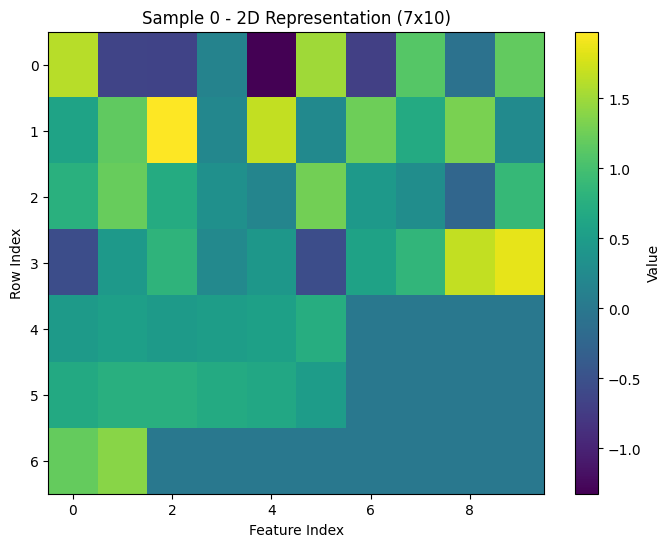

Sample values:
 [[ 1.62046727 -0.64528213 -0.66202055  0.15634944 -1.3235771   1.5056913
  -0.69197393  1.10594003 -0.0785735   1.18107942]
 [ 0.59509529  1.17372212  1.97659006  0.19847713  1.66807675  0.24168533
   1.24434995  0.68755452  1.31337612  0.25648707]
 [ 0.76978079  1.20312366  0.70299539  0.33757291  0.18404892  1.27940658
   0.45136064  0.29858116 -0.22819708  0.8848112 ]
 [-0.53930249  0.44408291  0.82705126  0.22888178  0.42688215 -0.54722546
   0.57794182  0.85134299  1.6728863   1.85657595]
 [ 0.46908018  0.53847057  0.47686994  0.51511283  0.5526504   0.72924462
   0.          0.          0.          0.        ]
 [ 0.68419116  0.75683477  0.76200656  0.69155978  0.64939923  0.50129561
   0.          0.          0.          0.        ]
 [ 1.1974957   1.38656564  0.          0.          0.          0.
   0.          0.          0.          0.        ]]
5396


In [140]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib
import sklearn
print("Phiên bản scikit-learn:", sklearn.__version__)

# Hàm chuyển sang 2D
def convert_1dto2d(input_1d):
    num_samples = input_1d.shape[0]
    output_2d = np.zeros((num_samples, 7, 10, 1))
    for i in range(num_samples):
        mfcc = input_1d[i, :40].reshape(4, 10)
        chroma = input_1d[i, 40:52].reshape(2, 6)
        spectral = input_1d[i, 52:54].reshape(1, 2)
        chroma_padded = np.pad(chroma, ((0, 0), (0, 4)), mode='constant')
        spectral_padded = np.pad(spectral, ((0, 0), (0, 8)), mode='constant')
        matrix_2d = np.vstack((mfcc, chroma_padded, spectral_padded))
        output_2d[i] = matrix_2d[..., np.newaxis]
    return output_2d


def make2dData( X_train, X_dev, X_test, name):
    
    scaler_mfcc = StandardScaler()
    scaler_chroma = MinMaxScaler()
    scaler_spectral = StandardScaler()
    
    # Chỉ fit trên tập train
    X_train_mfcc = scaler_mfcc.fit_transform(X_train[:, :40])
    X_train_chroma = scaler_chroma.fit_transform(X_train[:, 40:52])
    X_train_spectral = scaler_spectral.fit_transform(X_train[:, 52:54])
    
    X_dev_mfcc = scaler_mfcc.transform(X_dev[:, :40])
    X_dev_chroma = scaler_chroma.transform(X_dev[:, 40:52])
    X_dev_spectral = scaler_spectral.transform(X_dev[:, 52:54])
    
    X_test_mfcc = scaler_mfcc.transform(X_test[:, :40])
    X_test_chroma = scaler_chroma.transform(X_test[:, 40:52])
    X_test_spectral = scaler_spectral.transform(X_test[:, 52:54])

    # Lưu lại scaler để dùng cho dữ liệu thực tế sau này
    joblib.dump(scaler_mfcc, f"scaler_mfcc_{name}.pkl")
    joblib.dump(scaler_chroma, f"scaler_chroma_{name}.pkl")
    joblib.dump(scaler_spectral, f"scaler_spectral_{name}.pkl")
    
    # Gộp lại sau khi scale
    X_train_scaled = np.hstack((X_train_mfcc, X_train_chroma, X_train_spectral))
    X_dev_scaled = np.hstack((X_dev_mfcc, X_dev_chroma, X_dev_spectral))
    X_test_scaled = np.hstack((X_test_mfcc, X_test_chroma, X_test_spectral))
    
    X_train_2D = convert_1dto2d(X_train_scaled)
    X_dev_2D = convert_1dto2d(X_dev_scaled)
    X_test_2D = convert_1dto2d(X_test_scaled)
    
    
    return X_train_2D, X_dev_2D, X_test_2D


Xr_train_2D, Xr_dev_2D, Xr_test_2D = make2dData(Xr_train, Xr_dev, Xr_test, 'reg')
Xg_train_2D, Xg_dev_2D, Xg_test_2D = make2dData(Xg_train, Xg_dev, Xg_test, 'gen')

# Trực quan hóa một mẫu
sample_index = 0  # Chọn mẫu đầu tiên
sample = Xr_train_2D[sample_index, :, :, 0]  # Lấy dữ liệu 2D (7x10)

plt.figure(figsize=(8, 6))
plt.imshow(sample, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title(f'Sample {sample_index} - 2D Representation (7x10)')
plt.xlabel('Feature Index')
plt.ylabel('Row Index')
plt.show()

print("Sample values:\n", sample)
print( len(Xr_train_2D))

In [106]:

yr_train_cat = tf.keras.utils.to_categorical(yr_train -1, 3)  
yr_dev_cat = tf.keras.utils.to_categorical(yr_dev -1, 3)
yr_test_cat = tf.keras.utils.to_categorical(yr_test -1, 3)

yg_train_cat = tf.keras.utils.to_categorical(yg_train, 2) 
yg_dev_cat = tf.keras.utils.to_categorical(yg_dev, 2)
yg_test_cat = tf.keras.utils.to_categorical(yg_test, 2)

# Initialize Callbacks and Evaluate function

In [20]:
# Callbacks
def Callbacks(model):
    early_stopping = EarlyStopping(
        monitor='val_accuracy',  # Theo dõi độ chính xác trên tập validation
        patience=20,  # Chờ 20 epoch trước khi dừng
        restore_best_weights=True,  # Khôi phục trọng số tốt nhất
        mode='max',  # Tối đa hóa độ chính xác
        verbose=1  # Hiển thị thông báo
    )
    
    lr_reducer = ReduceLROnPlateau(
        monitor='val_loss',  # Theo dõi mất mát trên tập validation
        factor=0.3,  # Giảm learning rate xuống 30% khi không cải thiện
        patience=8,  # Chờ 8 epoch trước khi giảm
        min_lr=1e-6,  # Learning rate tối thiểu
        verbose=1  
    )
    
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f'best_{model}.keras',  # Lưu mô hình tốt nhất dưới dạng 'best_model.keras'
        monitor='val_accuracy',  # Theo dõi độ chính xác trên tập validation
        save_best_only=True,  # Chỉ lưu khi có cải thiện
        mode='max',  # Tối đa hóa độ chính xác
        verbose=1 
    )
    return lr_reducer, checkpoint, early_stopping

In [21]:
def Evaluateandlogperformance(model, history, X_test, y_test_cat,name ,detail=False):
    if detail:
        # Tải mô hình tốt nhất và đánh giá
        best_model = tf.keras.models.load_model(f'/kaggle/working/best_{name}.keras')
        # test_loss, test_accuracy = best_model.evaluate(X_test_scaled, y_test_cat)
        test_loss, test_accuracy = best_model.evaluate(X_test, y_test_cat)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
        dev_loss, dev_accuracy = best_model.evaluate(X_dev, y_dev_cat)
        print(f"Dev Loss: {dev_loss:.4f}, Dev Accuracy: {dev_accuracy:.4f}")
    
        # Ghi lại chi tiết hiệu suất
        print("\nDetailed Performance Summary:") 
        print(f"Training final accuracy: {history.history['accuracy'][-1]:.4f}")  
        print(f"Validation final accuracy: {history.history['val_accuracy'][-1]:.4f}")  
        print(f"Test final accuracy: {test_accuracy:.4f}")  
        print(f"Training final loss: {history.history['loss'][-1]:.4f}")  
        print(f"Validation final loss: {history.history['val_loss'][-1]:.4f}") 
        print(f"Test final loss: {test_loss:.4f}")  
        # Kiểm tra xem mục tiêu hiệu suất có đạt được không
        if dev_accuracy >= 0.8: 
            print("\n🎉 Target accuracy of 0.8 achieved on validation set!")  
        else:
            print("\n⚠️ Accuracy target of 0.8 not reached. Consider further improvements.") 


        
    # Sau khi huấn luyện xong, tính test accuracy và test loss
    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)  # Đánh giá mô hình trên tập kiểm tra

    
    # Vẽ biểu đồ lịch sử huấn luyện
    plt.figure(figsize=(12, 4))  # Tạo khung biểu đồ với kích thước 12x4
    
    plt.subplot(1, 2, 1)  # Biểu đồ con đầu tiên (bên trái)
    
    plt.plot(history.history['accuracy'], label='Training Accuracy')  # Vẽ đường độ chính xác huấn luyện
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # Vẽ đường độ chính xác validation
    plt.axhline(y=test_accuracy, color='r', linestyle='--', label='Test Accuracy')  # Vẽ đường ngang độ chính xác kiểm tra
    # Thêm văn bản để hiển thị giá trị test accuracy
    # Tự điều chỉnh vị trí chữ để không bị che
    acc_text_y = test_accuracy + 0.02 if test_accuracy < 0.97 else test_accuracy - 0.05
    
    plt.text(
        len(history.history['accuracy']) * 0.5,
        acc_text_y,
        f'{test_accuracy:.2f}',
        color='g', ha='center', va='bottom'
    )

    plt.title(f'Model Accuracy {name}')  
    plt.xlabel('Epoch')  # Nhãn trục x là Epoch
    plt.ylabel('Accuracy')  # Nhãn trục y là Độ chính xác
    plt.legend()  # Hiển thị chú thích
    
    plt.subplot(1, 2, 2)  
    
    plt.plot(history.history['loss'], label='Training Loss')  # Vẽ đường mất mát huấn luyện
    plt.plot(history.history['val_loss'], label='Validation Loss')  # Vẽ đường mất mát validation
    plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss')  # Vẽ đường ngang mất mát kiểm tra
    # Thêm văn bản để hiển thị giá trị test loss
    plt.text(len(history.history['loss']) * 0.5, test_loss + 0.02,  # Vị trí giữa trục x, trên đường kiểm tra
             f'{test_loss:.2f}',  # Giá trị mất mát với 2 chữ số thập phân
             color='g', ha='center', va='bottom') 
    plt.title(f'Model Loss {name}')  
    plt.xlabel('Epoch')  
    plt.ylabel('Loss') 
    plt.legend() 
    
    plt.figure(constrained_layout=True)   # Điều chỉnh lề để tránh lỗi
    plt.show()  


In [22]:
def compute_confusion_matrix(model, X_test, y_test, name, num_classes):
    # Dự đoán trên tập kiểm tra
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)  # Chuyển dự đoán từ xác suất sang lớp (class) bằng cách lấy giá trị lớn nhất
    y_test_classes = np.argmax(y_test, axis=1) # Chuyển nhãn thực tế từ dạng one-hot encoding sang lớp (class)
    
    # Tính ma trận nhầm lẫn
    cm = confusion_matrix(y_test_classes, y_pred_classes)
    
    # Vẽ ma trận nhầm lẫn
    plt.figure(figsize=(10, 8))  # Đặt kích thước biểu đồ
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Vẽ heatmap với số liệu chú thích
    plt.title(f'Confusion Matrix {name}')  
    plt.ylabel('True Label')  # Nhãn trục y: Nhãn thực tế
    plt.xlabel('Predicted Label')  # Nhãn trục x: Nhãn dự đoán
    plt.show()  
    
    # In báo cáo phân loại chi tiết (Precision, Recall, F1-score)
    print("\nClassification Report:")
    print(classification_report(y_test_classes, y_pred_classes))
    
    # Tính và in Precision, Recall trung bình theo từng lớp
    report = classification_report(y_test_classes, y_pred_classes, output_dict=True)
    print("\nDetailed Metrics by Class:")  # Chỉ số chi tiết theo lớp
    for i in range(num_classes):  # Lặp qua từng lớp
        print(f"\nClass {i}:")  # Lớp {i}
        print(f"Precision: {report[str(i)]['precision']:.4f}")  # Độ chính xác: tỷ lệ dự đoán đúng trong số dự đoán
        print(f"Recall: {report[str(i)]['recall']:.4f}")  # Độ nhạy: tỷ lệ phát hiện đúng các mẫu thực tế
        print(f"F1-score: {report[str(i)]['f1-score']:.4f}")  # F1-score: trung bình điều hòa của Precision và Recall
    
    # Tính và in các chỉ số trung bình (Hiển thị các chỉ số trung bình gia quyền của toàn bộ mô hình)
    print("\nOverall Metrics:")  # Chỉ số tổng thể
    print(f"Average Precision: {report['weighted avg']['precision']:.4f}")  # Độ chính xác trung bình
    print(f"Average Recall: {report['weighted avg']['recall']:.4f}")  # Độ nhạy trung bình
    print(f"Average F1-score: {report['weighted avg']['f1-score']:.4f}")  # F1-score trung bình

# Model

In [50]:
CNN2DRegion = Sequential()

# First Conv2D layer
CNN2DRegion.add(Conv2D(
    filters=96,  # filters_0
    kernel_size=5,  # kernel_size_0
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(7, 10, 1),
    kernel_regularizer=l2(0.008732453502912857)  # l2_conv_0
))
CNN2DRegion.add(BatchNormalization())
CNN2DRegion.add(MaxPooling2D(
    pool_size=2,  # pool_size_0
    strides=1,  # pool_strides_0
    padding='same'
))

# Second Conv2D layer
CNN2DRegion.add(Conv2D(
    filters=64,  # filters_1
    kernel_size=5,  # kernel_size_1
    strides=1,
    padding='same',
    activation='relu',
    kernel_regularizer=l2(0.0008307655913624025)  # l2_conv_1
))
CNN2DRegion.add(BatchNormalization())

# Dropout after Conv2D layers
CNN2DRegion.add(Dropout(rate=0.2))  # dropout_conv

# Flatten layer
CNN2DRegion.add(Flatten())

# First Dense layer
CNN2DRegion.add(Dense(
    units=96,  # units_0
    activation='relu',
    kernel_regularizer=l2(0.00036558483095598383)  # l2_dense_0
))
CNN2DRegion.add(BatchNormalization())
CNN2DRegion.add(Dropout(rate=0.3))  # dropout_dense_0

# Second Dense layer
CNN2DRegion.add(Dense(
    units=16,  # units_1
    activation='relu',
    kernel_regularizer=l2(0.0001129701550594694)  # l2_dense_1
))
CNN2DRegion.add(BatchNormalization())
CNN2DRegion.add(Dropout(rate=0.2))  # dropout_dense_1

# Output layer
CNN2DRegion.add(Dense(3, activation='softmax'))

# Compile the model
CNN2DRegion.compile(
    optimizer=Adam(learning_rate=0.00021682255492865924),  # learning_rate 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
CNN2DRegion.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 7, 10, 96)           │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 7, 10, 96)           │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 10, 96)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 10, 64)           │         153,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 7, 10, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 7, 10, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4480)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 96)                  │         430,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 589,027 (2.25 MB)

 Trainable params: 588,483 (2.24 MB)

 Non-trainable params: 544 (2.12 KB)

In [51]:
CNN2DGender = Sequential()

# First Conv2D layer
CNN2DGender.add(Conv2D(
    filters=96,  # filters_0
    kernel_size=5,  # kernel_size_0
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(7, 10, 1),
    kernel_regularizer=l2(0.008732453502912857)  # l2_conv_0
))
CNN2DGender.add(BatchNormalization())
CNN2DGender.add(MaxPooling2D(
    pool_size=2,  # pool_size_0
    strides=1,  # pool_strides_0
    padding='same'
))

# Second Conv2D layer
CNN2DGender.add(Conv2D(
    filters=64,  # filters_1
    kernel_size=5,  # kernel_size_1
    strides=1,
    padding='same',
    activation='relu',
    kernel_regularizer=l2(0.0008307655913624025)  # l2_conv_1
))
CNN2DGender.add(BatchNormalization())

# Dropout after Conv2D layers
CNN2DGender.add(Dropout(rate=0.2))  # dropout_conv

# Flatten layer
CNN2DGender.add(Flatten())

# First Dense layer
CNN2DGender.add(Dense(
    units=96,  # units_0
    activation='relu',
    kernel_regularizer=l2(0.00036558483095598383)  # l2_dense_0
))
CNN2DGender.add(BatchNormalization())
CNN2DGender.add(Dropout(rate=0.3))  # dropout_dense_0

# Second Dense layer
CNN2DGender.add(Dense(
    units=16,  # units_1
    activation='relu',
    kernel_regularizer=l2(0.0001129701550594694)  # l2_dense_1
))
CNN2DGender.add(BatchNormalization())
CNN2DGender.add(Dropout(rate=0.2))  # dropout_dense_1

# Output layer
CNN2DGender.add(Dense(2, activation='softmax'))

# Compile the model
CNN2DGender.compile(
    optimizer=Adam(learning_rate=0.00021682255492865924),  # learning_rate 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
CNN2DGender.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 7, 10, 96)           │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 7, 10, 96)           │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 10, 96)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 7, 10, 64)           │         153,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 7, 10, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 7, 10, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 4480)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 96)                  │         430,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 589,010 (2.25 MB)

 Trainable params: 588,466 (2.24 MB)

 Non-trainable params: 544 (2.12 KB)

In [52]:
lr_reducer, checkpoint, early_stopping = Callbacks('CNN2DRegion')
# Huấn luyện
historyCNN2DRegion = CNN2DRegion.fit(
    Xr_train_2D,  # Dữ liệu huấn luyện tăng cường
    yr_train_cat,  # Nhãn huấn luyện dạng one-hot
    epochs=200, 
    batch_size=64,  
    validation_data=(Xr_dev_2D, yr_dev_cat),  # Dữ liệu validation
    callbacks=[lr_reducer, checkpoint, early_stopping],  # Sử dụng các callback
    verbose=1  # Hiển thị tiến trình huấn luyện
)

Epoch 1/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6466 - loss: 0.9979
Epoch 1: val_accuracy improved from -inf to 0.35663, saving model to best_CNN2DRegion.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6472 - loss: 0.9966 - val_accuracy: 0.3566 - val_loss: 1.8869 - learning_rate: 2.1682e-04
Epoch 2/200
156/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8886 - loss: 0.4892
Epoch 2: val_accuracy did not improve from 0.35663
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8892 - loss: 0.4874 - val_accuracy: 0.3509 - val_loss: 1.7204 - learning_rate: 2.1682e-04
Epoch 3/200
162/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9365 - loss: 0.3703
Epoch 3: val_accuracy did not improve from 0.35663
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9366 - loss: 0.3696 - val_accuracy: 0.3502 - val_loss: 1.9250 - learning_rate: 2.1682e-04
Epoch 4/200
160/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9527 - loss: 0.3123
Epoch 4: val_accurac

In [53]:
lr_reducer, checkpoint, early_stopping = Callbacks('CNN2DGender')
# Huấn luyện
historyCNN2DGender = CNN2DGender.fit(
    Xg_train_2D,  # Dữ liệu huấn luyện tăng cường
    yg_train_cat,  # Nhãn huấn luyện dạng one-hot
    epochs=200, 
    batch_size=64,  
    validation_data=(Xg_dev_2D, yg_dev_cat),  # Dữ liệu validation
    callbacks=[lr_reducer, checkpoint, early_stopping],  # Sử dụng các callback
    verbose=1  # Hiển thị tiến trình huấn luyện
)

Epoch 1/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8315 - loss: 0.5455
Epoch 1: val_accuracy improved from -inf to 0.62767, saving model to best_CNN2DGender.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8319 - loss: 0.5447 - val_accuracy: 0.6277 - val_loss: 0.7628 - learning_rate: 2.1682e-04
Epoch 2/200
162/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9646 - loss: 0.2793
Epoch 2: val_accuracy improved from 0.62767 to 0.70471, saving model to best_CNN2DGender.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9647 - loss: 0.2790 - val_accuracy: 0.7047 - val_loss: 0.7033 - learning_rate: 2.1682e-04
Epoch 3/200
163/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9772 - loss: 0.2348
Epoch 3: val_accuracy did not improve from 0.70471
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9772 - loss: 0.2346 - val_accuracy: 0.6990 - val_loss: 0.9382 - learning_rate: 2.1682e-04
Epoch 4/200
161/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [55]:
CNN2DGender.summary()
CNN2DRegion.summary()
CNN2DGender.save('gender_model_normal.keras')
CNN2DRegion.save('region_model_normal.keras')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 7, 10, 96)           │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 7, 10, 96)           │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 10, 96)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 7, 10, 64)           │         153,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 7, 10, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 7, 10, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 4480)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 96)                  │         430,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,765,944 (6.74 MB)

 Trainable params: 588,466 (2.24 MB)

 Non-trainable params: 544 (2.12 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 7, 10, 96)           │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 7, 10, 96)           │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 10, 96)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 10, 64)           │         153,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 7, 10, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 7, 10, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4480)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 96)                  │         430,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,765,995 (6.74 MB)

 Trainable params: 588,483 (2.24 MB)

 Non-trainable params: 544 (2.12 KB)

 Optimizer params: 1,176,968 (4.49 MB)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4198 - loss: 2.2493 


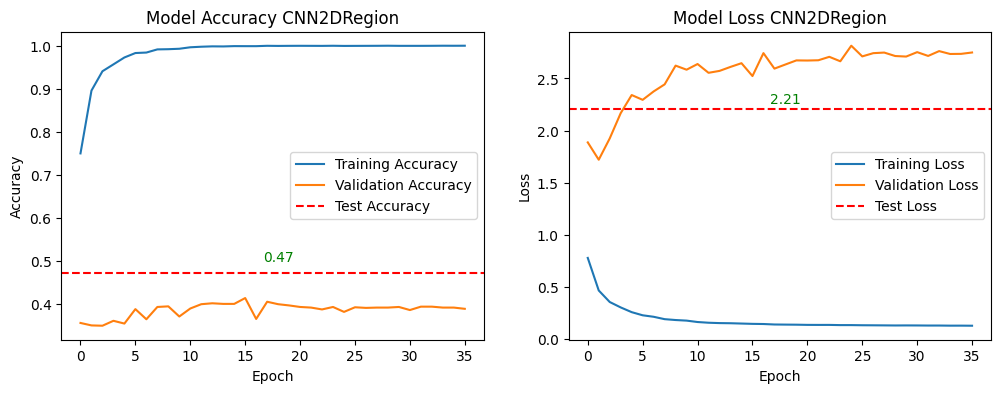

<Figure size 640x480 with 0 Axes>

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8835 - loss: 0.5783 


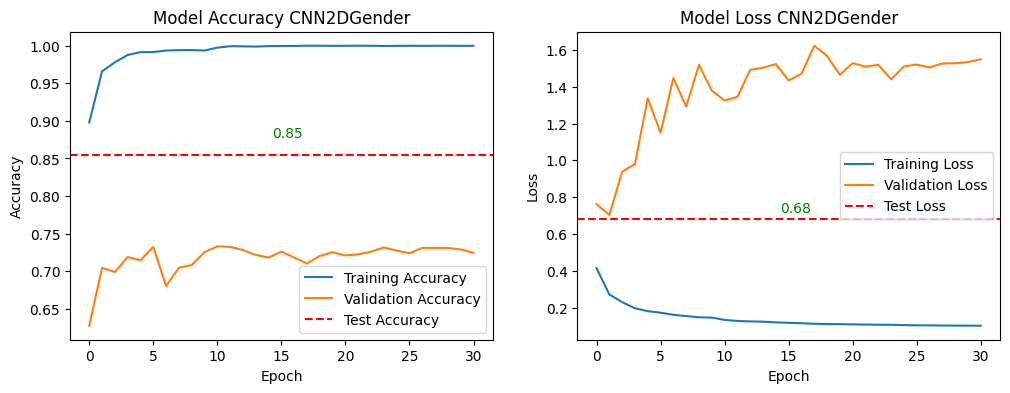

<Figure size 640x480 with 0 Axes>

In [54]:
Evaluateandlogperformance(CNN2DRegion, historyCNN2DRegion, Xr_test_2D, yr_test_cat, 'CNN2DRegion', detail = False)
Evaluateandlogperformance(CNN2DGender, historyCNN2DGender, Xg_test_2D, yg_test_cat, 'CNN2DGender', detail = False)


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


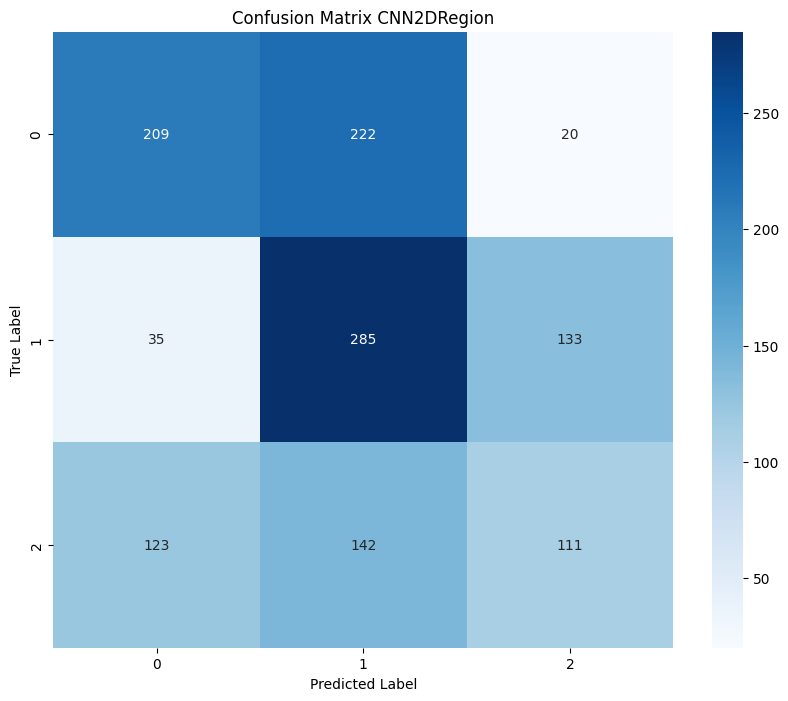


Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.46      0.51       451
           1       0.44      0.63      0.52       453
           2       0.42      0.30      0.35       376

    accuracy                           0.47      1280
   macro avg       0.48      0.46      0.46      1280
weighted avg       0.48      0.47      0.46      1280


Detailed Metrics by Class:

Class 0:
Precision: 0.5695
Recall: 0.4634
F1-score: 0.5110

Class 1:
Precision: 0.4391
Recall: 0.6291
F1-score: 0.5172

Class 2:
Precision: 0.4205
Recall: 0.2952
F1-score: 0.3469

Overall Metrics:
Average Precision: 0.4796
Average Recall: 0.4727
Average F1-score: 0.4650
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


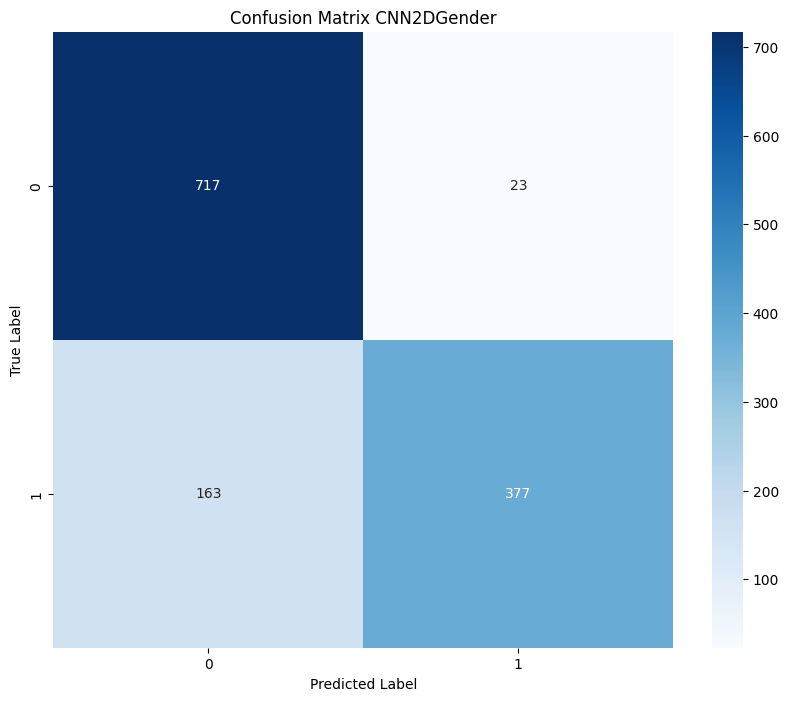


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.97      0.89       740
           1       0.94      0.70      0.80       540

    accuracy                           0.85      1280
   macro avg       0.88      0.83      0.84      1280
weighted avg       0.87      0.85      0.85      1280


Detailed Metrics by Class:

Class 0:
Precision: 0.8148
Recall: 0.9689
F1-score: 0.8852

Class 1:
Precision: 0.9425
Recall: 0.6981
F1-score: 0.8021

Overall Metrics:
Average Precision: 0.8687
Average Recall: 0.8547
Average F1-score: 0.8501


In [56]:
compute_confusion_matrix(CNN2DRegion, Xr_test_2D, yr_test_cat, 'CNN2DRegion', 3)
compute_confusion_matrix(CNN2DGender, Xg_test_2D, yg_test_cat, 'CNN2DGender', 2)

# Keras Tuner

In [107]:
# Hàm xây dựng mô hình với Keras Tuner
def build_region(hp):
    model = Sequential()

    # First Conv2D layer
    filters_0 = hp.Int('filters_0', min_value=16, max_value=96, step=16)
    kernel_size_0 = hp.Choice('kernel_size_0', values=[3, 5])
    l2_conv_0 = hp.Float('l2_conv_0', min_value=1e-4, max_value=1e-2, sampling='log')
    
    model.add(Conv2D(
        filters=filters_0,
        kernel_size=kernel_size_0,
        strides=1,
        padding='same',
        activation='relu',
        input_shape=(7, 10, 1),
        kernel_regularizer=l2(l2_conv_0)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(
        pool_size=hp.Choice('pool_size_0', values=[2, 3]),
        strides=1,
        padding='same'
    ))

    # Second Conv2D layer (tùy chọn)
    include_conv1 = hp.Boolean('include_conv1')
    if include_conv1:
        filters_1 = hp.Int('filters_1', min_value=16, max_value=64, step=16)
        kernel_size_1 = hp.Choice('kernel_size_1', values=[3, 5])
        l2_conv_1 = hp.Float('l2_conv_1', min_value=1e-4, max_value=1e-2, sampling='log')
        
        model.add(Conv2D(
            filters=filters_1,
            kernel_size=kernel_size_1,
            strides=1,
            padding='same',
            activation='relu',
            kernel_regularizer=l2(l2_conv_1)
        ))
        model.add(BatchNormalization())

    # Dropout sau Conv layers
    dropout_conv = hp.Float('dropout_conv', min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(rate=dropout_conv))

    # Flatten
    model.add(Flatten())

    # First Dense layer (tùy chọn)
    include_dense0 = hp.Boolean('include_dense0')
    if include_dense0:
        units_0 = hp.Int('units_0', min_value=16, max_value=96, step=16)
        l2_dense_0 = hp.Float('l2_dense_0', min_value=1e-4, max_value=1e-2, sampling='log')
        dropout_dense_0 = hp.Float('dropout_dense_0', min_value=0.0, max_value=0.5, step=0.1)
        
        model.add(Dense(
            units=units_0,
            activation='relu',
            kernel_regularizer=l2(l2_dense_0)
        ))
        model.add(BatchNormalization())
        model.add(Dropout(rate=dropout_dense_0))

    # Second Dense layer
    units_1 = hp.Int('units_1', min_value=8, max_value=32, step=8)
    l2_dense_1 = hp.Float('l2_dense_1', min_value=1e-4, max_value=1e-2, sampling='log')
    dropout_dense_1 = hp.Float('dropout_dense_1', min_value=0.0, max_value=0.5, step=0.1)
    
    model.add(Dense(
        units=units_1,
        activation='relu',
        kernel_regularizer=l2(l2_dense_1)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(rate=dropout_dense_1))

    # Output layer (3 lớp cho region)
    model.add(Dense(3, activation='softmax'))

    # Compile model
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model
    
# EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

tuner_region = kt.Hyperband(
    build_region,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    directory='tuner_dir2',
    project_name='cnn2d_region_hyperband'
)

Reloading Tuner from tuner_dir2/cnn2d_region_hyperband/tuner0.json


In [108]:
# Hàm xây dựng mô hình với Keras Tuner
def build_gender(hp):
    model = Sequential()

    # First Conv2D layer
    filters_0 = hp.Int('filters_0', min_value=16, max_value=96, step=16)
    kernel_size_0 = hp.Choice('kernel_size_0', values=[3, 5])
    l2_conv_0 = hp.Float('l2_conv_0', min_value=1e-4, max_value=1e-2, sampling='log')
    
    model.add(Conv2D(
        filters=filters_0,
        kernel_size=kernel_size_0,
        strides=1,
        padding='same',
        activation='relu',
        input_shape=(7, 10, 1),
        kernel_regularizer=l2(l2_conv_0)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(
        pool_size=hp.Choice('pool_size_0', values=[2, 3]),
        strides=1,
        padding='same'
    ))

    # Second Conv2D layer (tùy chọn)
    include_conv1 = hp.Boolean('include_conv1')
    if include_conv1:
        filters_1 = hp.Int('filters_1', min_value=16, max_value=64, step=16)
        kernel_size_1 = hp.Choice('kernel_size_1', values=[3, 5])
        l2_conv_1 = hp.Float('l2_conv_1', min_value=1e-4, max_value=1e-2, sampling='log')
        
        model.add(Conv2D(
            filters=filters_1,
            kernel_size=kernel_size_1,
            strides=1,
            padding='same',
            activation='relu',
            kernel_regularizer=l2(l2_conv_1)
        ))
        model.add(BatchNormalization())

    # Dropout sau Conv layers
    dropout_conv = hp.Float('dropout_conv', min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(rate=dropout_conv))

    # Flatten
    model.add(Flatten())

    # First Dense layer (tùy chọn)
    include_dense0 = hp.Boolean('include_dense0')
    if include_dense0:
        units_0 = hp.Int('units_0', min_value=16, max_value=96, step=16)
        l2_dense_0 = hp.Float('l2_dense_0', min_value=1e-4, max_value=1e-2, sampling='log')
        dropout_dense_0 = hp.Float('dropout_dense_0', min_value=0.0, max_value=0.5, step=0.1)
        
        model.add(Dense(
            units=units_0,
            activation='relu',
            kernel_regularizer=l2(l2_dense_0)
        ))
        model.add(BatchNormalization())
        model.add(Dropout(rate=dropout_dense_0))

    # Second Dense layer
    units_1 = hp.Int('units_1', min_value=8, max_value=32, step=8)
    l2_dense_1 = hp.Float('l2_dense_1', min_value=1e-4, max_value=1e-2, sampling='log')
    dropout_dense_1 = hp.Float('dropout_dense_1', min_value=0.0, max_value=0.5, step=0.1)
    
    model.add(Dense(
        units=units_1,
        activation='relu',
        kernel_regularizer=l2(l2_dense_1)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(rate=dropout_dense_1))

    # Output layer (3 lớp cho region)
    model.add(Dense(2, activation='softmax'))

    # Compile model
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


# EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

tuner_gender = kt.Hyperband(
    build_gender,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    directory='tuner_dir2',
    project_name='cnn2d_gender_hyperband'
)

Reloading Tuner from tuner_dir2/cnn2d_gender_hyperband/tuner0.json


In [109]:
# Tìm kiếm mô hình
tuner_region.search(
    Xr_train_2D, yr_train_cat, 
    epochs=100, batch_size=64,
    validation_data=(Xr_dev_2D, yr_dev_cat), 
    callbacks=[early_stopping], verbose=2 
)

Trial 60 Complete [00h 00m 14s]
val_accuracy: 0.9440069794654846

Best val_accuracy So Far: 0.9816272854804993
Total elapsed time: 00h 13m 37s

In [110]:
# Lấy mô hình tốt nhất
best_model = tuner_region.get_best_models(num_models=1)[0]
best_hyperparameters = tuner_region.get_best_hyperparameters(num_trials=1)[0]

# In thông tin mô hình tốt nhất
print("Best hyperparameters:")
for param, value in best_hyperparameters.values.items():
    print(f"{param}: {value}")
best_model.summary()

# Đánh giá trên tập test
test_loss, test_accuracy = best_model.evaluate(Xr_test_2D, yr_test_cat)
print("Test accuracy:", test_accuracy)

# Lưu mô hình nhẹ nhất
best_model.save("cnn2d_region_light_hyperband.keras")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best hyperparameters:
filters_0: 80
kernel_size_0: 5
l2_conv_0: 0.0009407757563332102
pool_size_0: 2
include_conv1: True
dropout_conv: 0.0
include_dense0: True
units_1: 8
l2_dense_1: 0.0007383436520516292
dropout_dense_1: 0.2
learning_rate: 0.0005623425672652072
filters_1: 32
kernel_size_1: 5
l2_conv_1: 0.0006007648451425429
units_0: 80
l2_dense_0: 0.006952832162532451
dropout_dense_0: 0.1
tuner/epochs: 10
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0


/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 7, 10, 80)           │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 10, 80)           │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 7, 10, 80)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 10, 32)           │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 10, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 10, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2240)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 80)                  │         179,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 80)                  │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 246,867 (964.32 KB)

 Trainable params: 246,467 (962.76 KB)

 Non-trainable params: 400 (1.56 KB)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3940 - loss: 1.8474 
Test accuracy: 0.5023437738418579


Best hyperparameters:
filters_0: 80
kernel_size_0: 5
l2_conv_0: 0.0009407757563332102
pool_size_0: 2
include_conv1: True
dropout_conv: 0.0
include_dense0: True
units_1: 8
l2_dense_1: 0.0007383436520516292
dropout_dense_1: 0.2
learning_rate: 0.0005623425672652072
filters_1: 32
kernel_size_1: 5
l2_conv_1: 0.0006007648451425429
units_0: 80
l2_dense_0: 0.006952832162532451
dropout_dense_0: 0.1
tuner/epochs: 10
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0

In [111]:
# Tìm kiếm mô hình
tuner_gender.search(
    Xg_train_2D, yg_train_cat, 
    epochs=100, batch_size=64,
    validation_data=(Xg_dev_2D, yg_dev_cat), 
    callbacks=[early_stopping], verbose=2 
)

Trial 60 Complete [00h 00m 24s]
val_accuracy: 0.9503105878829956

Best val_accuracy So Far: 0.9856665134429932
Total elapsed time: 00h 15m 31s

In [112]:
# Lấy mô hình tốt nhất
best_model = tuner_gender.get_best_models(num_models=1)[0]
best_hyperparameters = tuner_gender.get_best_hyperparameters(num_trials=1)[0]

# In thông tin mô hình tốt nhất
print("Best hyperparameters:")
for param, value in best_hyperparameters.values.items():
    print(f"{param}: {value}")
best_model.summary()

# Đánh giá trên tập test
test_loss, test_accuracy = best_model.evaluate(Xg_test_2D, yg_test_cat)
print("Test accuracy:", test_accuracy)

# Lưu mô hình nhẹ nhất
best_model.save("cnn2d_gender_light_hyperband.keras")

Best hyperparameters:
filters_0: 48
kernel_size_0: 5
l2_conv_0: 0.00013018329843895806
pool_size_0: 2
include_conv1: True
dropout_conv: 0.0
include_dense0: True
units_1: 24
l2_dense_1: 0.003451000688272909
dropout_dense_1: 0.1
learning_rate: 0.0004257494904478956
units_0: 48
l2_dense_0: 0.0004731779586917222
dropout_dense_0: 0.0
filters_1: 16
kernel_size_1: 3
l2_conv_1: 0.0002666980361332198
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0049


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 7, 10, 48)           │           1,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 10, 48)           │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 7, 10, 48)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 10, 16)           │           6,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 10, 16)           │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 10, 16)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1120)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 48)                  │          53,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 63,754 (249.04 KB)

 Trainable params: 63,482 (247.98 KB)

 Non-trainable params: 272 (1.06 KB)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8741 - loss: 0.5210
Test accuracy: 0.848437488079071


Best hyperparameters:
filters_0: 48
kernel_size_0: 5
l2_conv_0: 0.00013018329843895806
pool_size_0: 2
include_conv1: True
dropout_conv: 0.0
include_dense0: True
units_1: 24
l2_dense_1: 0.003451000688272909
dropout_dense_1: 0.1
learning_rate: 0.0004257494904478956
units_0: 48
l2_dense_0: 0.0004731779586917222
dropout_dense_0: 0.0
filters_1: 16
kernel_size_1: 3
l2_conv_1: 0.0002666980361332198
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0049

# Apply hyperparameters

In [113]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Xây dựng mô hình CNN2DRegionHyper với siêu tham số mới
CNN2DRegionHyper = Sequential()

# First Conv2D layer
CNN2DRegionHyper.add(Conv2D(
    filters=80,  # filters_0
    kernel_size=5,  # kernel_size_0
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(7, 10, 1),
    kernel_regularizer=l2(0.0009407757563332102)  # l2_conv_0
))
CNN2DRegionHyper.add(BatchNormalization())
CNN2DRegionHyper.add(MaxPooling2D(
    pool_size=2,  # pool_size_0
    strides=1,
    padding='same'
))

# Second Conv2D layer (include_conv1 = True)
CNN2DRegionHyper.add(Conv2D(
    filters=32,  # filters_1
    kernel_size=5,  # kernel_size_1
    strides=1,
    padding='same',
    activation='relu',
    kernel_regularizer=l2(0.0006007648451425429)  # l2_conv_1
))
CNN2DRegionHyper.add(BatchNormalization())

# Dropout after Conv2D layers
CNN2DRegionHyper.add(Dropout(rate=0.0))  # dropout_conv

# Flatten layer
CNN2DRegionHyper.add(Flatten())

# First Dense layer (include_dense0 = True)
CNN2DRegionHyper.add(Dense(
    units=80,  # units_0
    activation='relu',
    kernel_regularizer=l2(0.006952832162532451)  # l2_dense_0
))
CNN2DRegionHyper.add(BatchNormalization())
CNN2DRegionHyper.add(Dropout(rate=0.1))  # dropout_dense_0

# Second Dense layer
CNN2DRegionHyper.add(Dense(
    units=8,  # units_1
    activation='relu',
    kernel_regularizer=l2(0.0007383436520516292)  # l2_dense_1
))
CNN2DRegionHyper.add(BatchNormalization())
CNN2DRegionHyper.add(Dropout(rate=0.2))  # dropout_dense_1

# Output layer
CNN2DRegionHyper.add(Dense(3, activation='softmax'))  # 3 lớp: Southern, Central, Northern

# Compile the model
CNN2DRegionHyper.compile(
    optimizer=Adam(learning_rate=0.0005623425672652072),  # learning_rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Hiển thị tóm tắt mô hình
CNN2DRegionHyper.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 7, 10, 80)           │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 7, 10, 80)           │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 10, 80)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 10, 32)           │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 7, 10, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 7, 10, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2240)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 80)                  │         179,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 80)                  │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 246,867 (964.32 KB)

 Trainable params: 246,467 (962.76 KB)

 Non-trainable params: 400 (1.56 KB)

In [114]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Xây dựng mô hình CNN2DGenderHyper với hyperparameters mới
CNN2DGenderHyper = Sequential()

# First Conv2D layer
CNN2DGenderHyper.add(Conv2D(
    filters=48,  # filters_0
    kernel_size=5,  # kernel_size_0
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(7, 10, 1),
    kernel_regularizer=l2(0.00013018329843895806)  # l2_conv_0
))
CNN2DGenderHyper.add(BatchNormalization())
CNN2DGenderHyper.add(MaxPooling2D(
    pool_size=2,  # pool_size_0
    strides=1,
    padding='same'
))

# Second Conv2D layer (include_conv1 = True)
CNN2DGenderHyper.add(Conv2D(
    filters=16,  # filters_1
    kernel_size=3,  # kernel_size_1
    strides=1,
    padding='same',
    activation='relu',
    kernel_regularizer=l2(0.0002666980361332198)  # l2_conv_1
))
CNN2DGenderHyper.add(BatchNormalization())

# Dropout after Conv2D layers
CNN2DGenderHyper.add(Dropout(rate=0.0))  # dropout_conv

# Flatten layer
CNN2DGenderHyper.add(Flatten())

# First Dense layer (include_dense0 = True)
CNN2DGenderHyper.add(Dense(
    units=48,  # units_0
    activation='relu',
    kernel_regularizer=l2(0.0004731779586917222)  # l2_dense_0
))
CNN2DGenderHyper.add(BatchNormalization())
CNN2DGenderHyper.add(Dropout(rate=0.0))  # dropout_dense_0

# Second Dense layer
CNN2DGenderHyper.add(Dense(
    units=24,  # units_1
    activation='relu',
    kernel_regularizer=l2(0.003451000688272909)  # l2_dense_1
))
CNN2DGenderHyper.add(BatchNormalization())
CNN2DGenderHyper.add(Dropout(rate=0.1))  # dropout_dense_1

# Output layer
CNN2DGenderHyper.add(Dense(2, activation='softmax'))  # 2 lớp: Male, Female

# Compile the model
CNN2DGenderHyper.compile(
    optimizer=Adam(learning_rate=0.0004257494904478956),  # learning_rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Hiển thị tóm tắt mô hình
CNN2DGenderHyper.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 7, 10, 48)           │           1,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 7, 10, 48)           │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 10, 48)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 10, 16)           │           6,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 7, 10, 16)           │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 7, 10, 16)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1120)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 48)                  │          53,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 63,754 (249.04 KB)

 Trainable params: 63,482 (247.98 KB)

 Non-trainable params: 272 (1.06 KB)

In [115]:
lr_reducer, checkpoint, early_stopping = Callbacks('CNN2DRegionHyper')
# Huấn luyện
historyCNN2DRegionHyper = CNN2DRegionHyper.fit(
    Xr_train_2D,  # Dữ liệu huấn luyện tăng cường
    yr_train_cat,  # Nhãn huấn luyện dạng one-hot
    epochs=200, 
    batch_size=64,  
    validation_data=(Xr_dev_2D, yr_dev_cat),  # Dữ liệu validation
    callbacks=[lr_reducer, checkpoint, early_stopping],  # Sử dụng các callback
    verbose=1  # Hiển thị tiến trình huấn luyện
)

Epoch 1/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6086 - loss: 1.9563
Epoch 1: val_accuracy improved from -inf to 0.29244, saving model to best_CNN2DRegionHyper.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.6098 - loss: 1.9537 - val_accuracy: 0.2924 - val_loss: 2.4884 - learning_rate: 5.6234e-04
Epoch 2/200
72/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8415 - loss: 1.3049
Epoch 2: val_accuracy did not improve from 0.29244
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8446 - loss: 1.2903 - val_accuracy: 0.2375 - val_loss: 2.2692 - learning_rate: 5.6234e-04
Epoch 3/200
72/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9223 - loss: 0.9393
Epoch 3: val_accuracy improved from 0.29244 to 0.30100, saving model to best_CNN2DRegionHyper.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9220 - loss: 0.9315 - val_accuracy: 0.3010 - val_loss: 2.1248 - learning_rate: 5.6234e-04
Epoch 4/200
73/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.

In [116]:
lr_reducer, checkpoint, early_stopping = Callbacks('CNN2DGenderHyper')
# Huấn luyện
historyCNN2DGenderHyper = CNN2DGenderHyper.fit(
    Xg_train_2D,  # Dữ liệu huấn luyện tăng cường
    yg_train_cat,  # Nhãn huấn luyện dạng one-hot
    epochs=200, 
    batch_size=64,  
    validation_data=(Xg_dev_2D, yg_dev_cat),  # Dữ liệu validation
    callbacks=[lr_reducer, checkpoint, early_stopping],  # Sử dụng các callback
    verbose=1  # Hiển thị tiến trình huấn luyện
)

Epoch 1/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7830 - loss: 0.6457
Epoch 1: val_accuracy improved from -inf to 0.61270, saving model to best_CNN2DGenderHyper.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.7838 - loss: 0.6440 - val_accuracy: 0.6127 - val_loss: 0.7931 - learning_rate: 4.2575e-04
Epoch 2/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9400 - loss: 0.3201
Epoch 2: val_accuracy improved from 0.61270 to 0.63338, saving model to best_CNN2DGenderHyper.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9401 - loss: 0.3199 - val_accuracy: 0.6334 - val_loss: 0.7673 - learning_rate: 4.2575e-04
Epoch 3/200
83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9730 - loss: 0.2452
Epoch 3: val_accuracy improved from 0.63338 to 0.67190, saving model to best_CNN2DGenderHyper.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9730 - loss: 0.2450 - val_accuracy: 0.6719 - val_loss: 0.7318 - learning_rate: 4.2575e-04
Epoch 4/200
78/8

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3148 - loss: 2.0004 


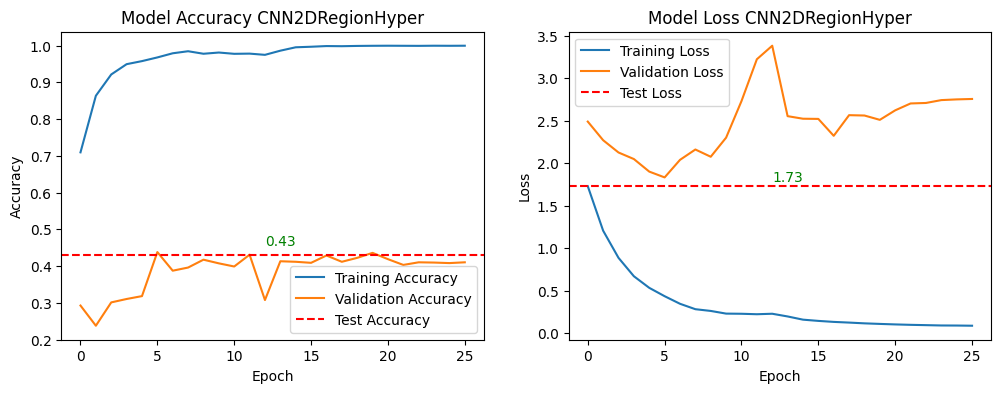

<Figure size 640x480 with 0 Axes>

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8706 - loss: 0.4561 


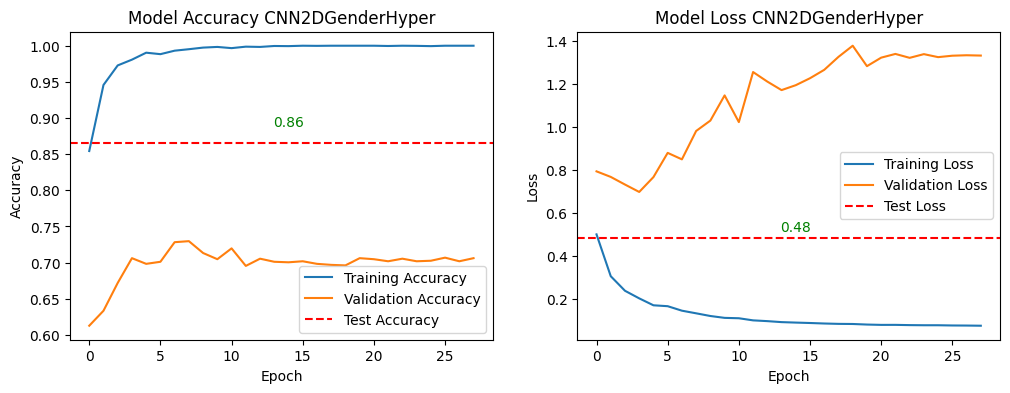

<Figure size 640x480 with 0 Axes>

In [117]:
Evaluateandlogperformance(CNN2DRegionHyper, historyCNN2DRegionHyper, Xr_test_2D, yr_test_cat, 'CNN2DRegionHyper', detail = False)
Evaluateandlogperformance(CNN2DGenderHyper, historyCNN2DGenderHyper, Xg_test_2D, yg_test_cat, 'CNN2DGenderHyper', detail = False)


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


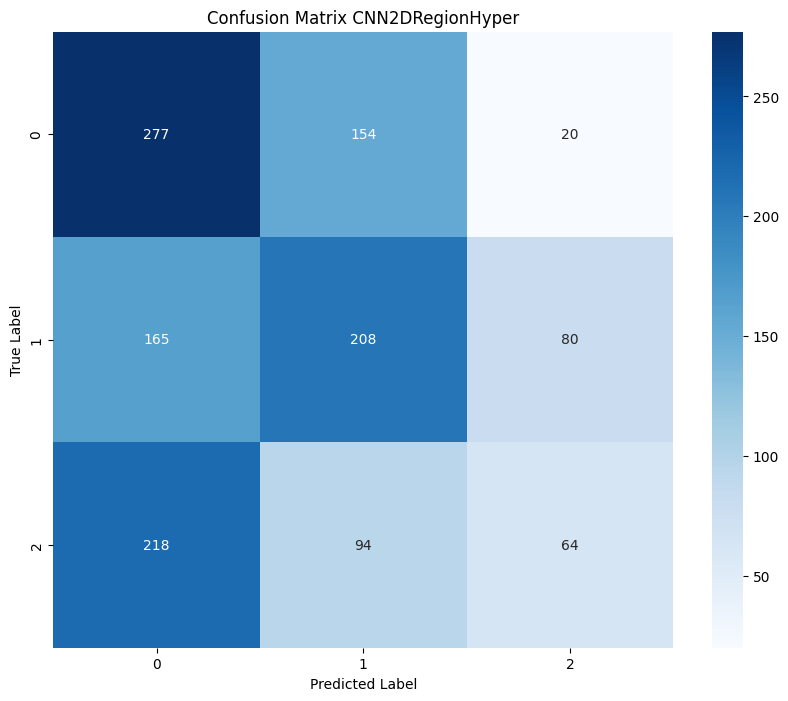


Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.61      0.50       451
           1       0.46      0.46      0.46       453
           2       0.39      0.17      0.24       376

    accuracy                           0.43      1280
   macro avg       0.42      0.41      0.40      1280
weighted avg       0.42      0.43      0.41      1280


Detailed Metrics by Class:

Class 0:
Precision: 0.4197
Recall: 0.6142
F1-score: 0.4986

Class 1:
Precision: 0.4561
Recall: 0.4592
F1-score: 0.4576

Class 2:
Precision: 0.3902
Recall: 0.1702
F1-score: 0.2370

Overall Metrics:
Average Precision: 0.4239
Average Recall: 0.4289
Average F1-score: 0.4073
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


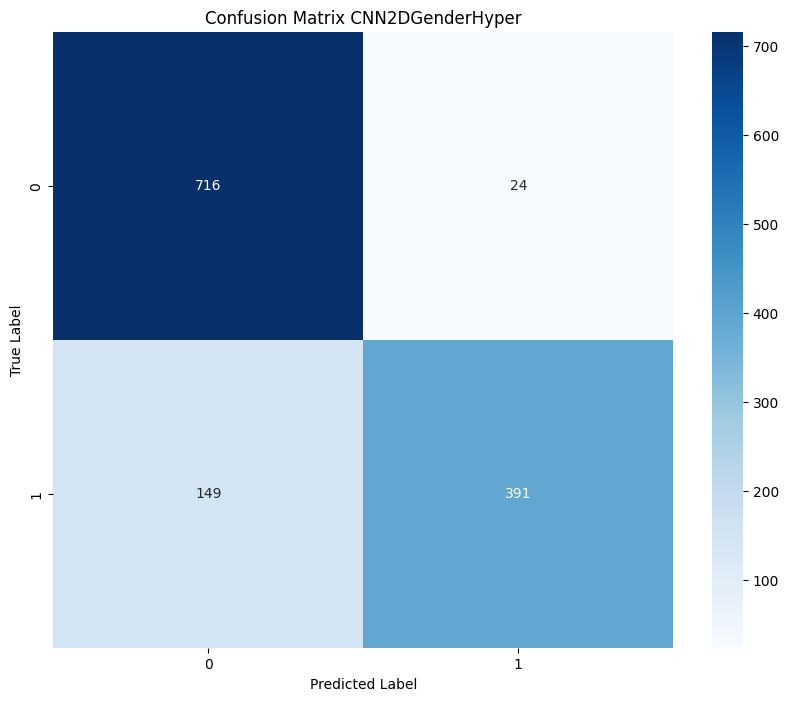


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89       740
           1       0.94      0.72      0.82       540

    accuracy                           0.86      1280
   macro avg       0.88      0.85      0.86      1280
weighted avg       0.88      0.86      0.86      1280


Detailed Metrics by Class:

Class 0:
Precision: 0.8277
Recall: 0.9676
F1-score: 0.8922

Class 1:
Precision: 0.9422
Recall: 0.7241
F1-score: 0.8188

Overall Metrics:
Average Precision: 0.8760
Average Recall: 0.8648
Average F1-score: 0.8613


In [118]:
compute_confusion_matrix(CNN2DRegionHyper, Xr_test_2D, yr_test_cat, 'CNN2DRegionHyper', 3)
compute_confusion_matrix(CNN2DGenderHyper, Xg_test_2D, yg_test_cat, 'CNN2DGenderHyper', 2)

In [119]:
CNN2DRegionHyper.summary()
CNN2DGenderHyper.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 7, 10, 80)           │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 7, 10, 80)           │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 10, 80)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 10, 32)           │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 7, 10, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 7, 10, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2240)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 80)                  │         179,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 80)                  │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 739,803 (2.82 MB)

 Trainable params: 246,467 (962.76 KB)

 Non-trainable params: 400 (1.56 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 7, 10, 48)           │           1,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 7, 10, 48)           │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 10, 48)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 10, 16)           │           6,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 7, 10, 16)           │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 7, 10, 16)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1120)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 48)                  │          53,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 190,720 (745.00 KB)

 Trainable params: 63,482 (247.98 KB)

 Non-trainable params: 272 (1.06 KB)

 Optimizer params: 126,966 (495.96 KB)

In [120]:
CNN2DRegionHyper.save('best_region_recognition_model.keras')
CNN2DGenderHyper.save("best_gender_recognition_model.keras")

# ReProcessing

## Extract features

In [61]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

(-1) Central: 2735 WAV files
(-1) Central (only_vocal): 2119 WAV files
(-1) North: 2819 WAV files
(-1) North (only_vocal): 2049 WAV files
(-1) South: 2364 WAV files
(-1) South (only_vocal): 1862 WAV files
(-2) Central: 2735 WAV files
(-2) Central (only_vocal): 2119 WAV files
(-2) North: 2819 WAV files
(-2) North (only_vocal): 2049 WAV files
(-2) South: 2364 WAV files
(-2) South (only_vocal): 1862 WAV files
Central: 2777 WAV files
Central (only_vocal): 2155 WAV files
North: 2857 WAV files
North (only_vocal): 2081 WAV files
South: 2444 WAV files
South (only_vocal): 1926 WAV files


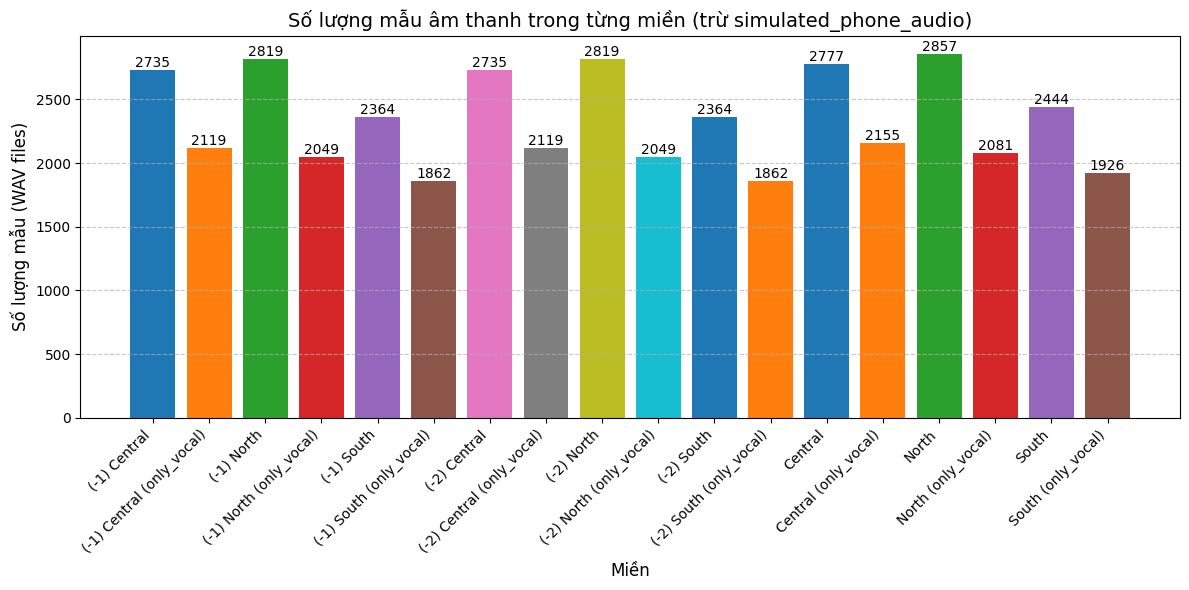

Saved chart to /kaggle/working/sample_counts_by_region.png


<Figure size 640x480 with 0 Axes>

In [62]:
import os
import matplotlib.pyplot as plt

# Đường dẫn đến thư mục dữ liệu
INPUT_DIR = "/kaggle/input/vietnamese-accent-3-regions"

# Lấy danh sách tất cả các thư mục miền, bao gồm -1 và -2
def get_regions():
    regions = []
    for region in os.listdir(INPUT_DIR):
        if os.path.isdir(os.path.join(INPUT_DIR, region)):
            # Loại trừ thư mục có "simulated_phone_audio"
            if "simulated_phone_audio" not in region.lower():
                regions.append(region)
    return sorted(regions)  # Sắp xếp để hiển thị nhất quán

REGIONS = get_regions()

def count_wav_files(region):
    """Đếm số file WAV trong thư mục của một miền, trừ thư mục simulated_phone_audio."""
    region_path = os.path.join(INPUT_DIR, region)
    if not os.path.isdir(region_path):
        return 0
    
    total_wav = 0
    for sub_dir in os.listdir(region_path):
        sub_path = os.path.join(region_path, sub_dir)
        # Bỏ qua nếu thư mục con chứa "simulated_phone_audio"
        if "simulated_phone_audio" in sub_dir.lower():
            continue
        if os.path.isdir(sub_path):
            # Đếm file WAV trong thư mục con
            wav_files = [f for f in os.listdir(sub_path) if f.endswith(".wav")]
            total_wav += len(wav_files)
    
    return total_wav

# Thu thập số lượng mẫu cho từng miền
sample_counts = {}
for region in REGIONS:
    count = count_wav_files(region)
    sample_counts[region] = count
    print(f"{region}: {count} WAV files")

# Vẽ biểu đồ cột
plt.figure(figsize=(12, 6))
bars = plt.bar(sample_counts.keys(), sample_counts.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 
                                                                  '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', 
                                                                  '#bcbd22', '#17becf', '#1f77b4', '#ff7f0e'])

# Tùy chỉnh biểu đồ
plt.xlabel("Miền", fontsize=12)
plt.ylabel("Số lượng mẫu (WAV files)", fontsize=12)
plt.title("Số lượng mẫu âm thanh trong từng miền (trừ simulated_phone_audio)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm số lượng trên mỗi cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Lưu biểu đồ
plt.savefig("/kaggle/working/sample_counts_by_region.png", dpi=300, bbox_inches='tight')
print("Saved chart to /kaggle/working/sample_counts_by_region.png")

region Counts:
North: 14674
Central: 14640
South: 12822


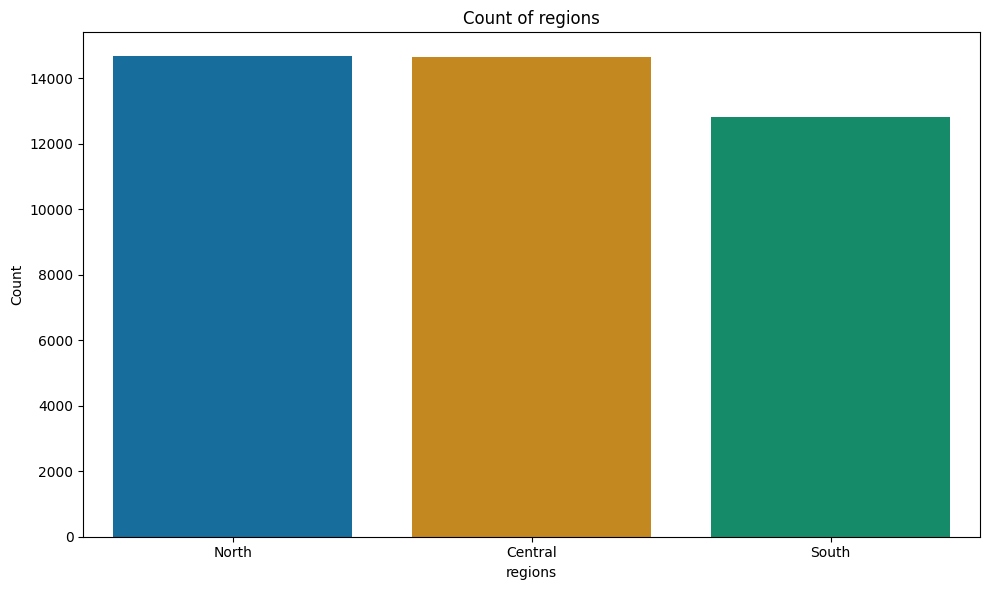

In [63]:
# Đường dẫn tới thư mục chứa tập dữ liệu
path = "/kaggle/input/vietnamese-accent-3-regions/***/**/*.wav"

# Mapping RAVDESS numeric encoding to regions
region_map = {
    '1': 'North',
    '2': 'Central',
    '3': 'South',
}

# Extract region labels from filenames
filenames = glob.glob(path, recursive=True)
regions = [region_map[os.path.basename(f).split('-')[0]] for f in filenames if os.path.basename(f).split('-')[0] in region_map]

# Count occurrences of each region
region_counts = Counter(regions)

# Sort regions by predefined order
region_order = ['North', 'Central', 'South']
counts = [region_counts[r] for r in region_order if r in region_counts]

# Print the count of each region
print("region Counts:")
for region in region_order:
    count = region_counts.get(region, 0)
    print(f"{region}: {count}")

# Plot the region distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=pd.Series(region_order), y=counts, palette="colorblind")
plt.xlabel("regions")
plt.ylabel("Count")
plt.title("Count of regions")
plt.tight_layout()
plt.show()

Region Counts:
North: 14674
Central: 14640
South: 12822


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


Saved chart to /kaggle/working/region_counts.png


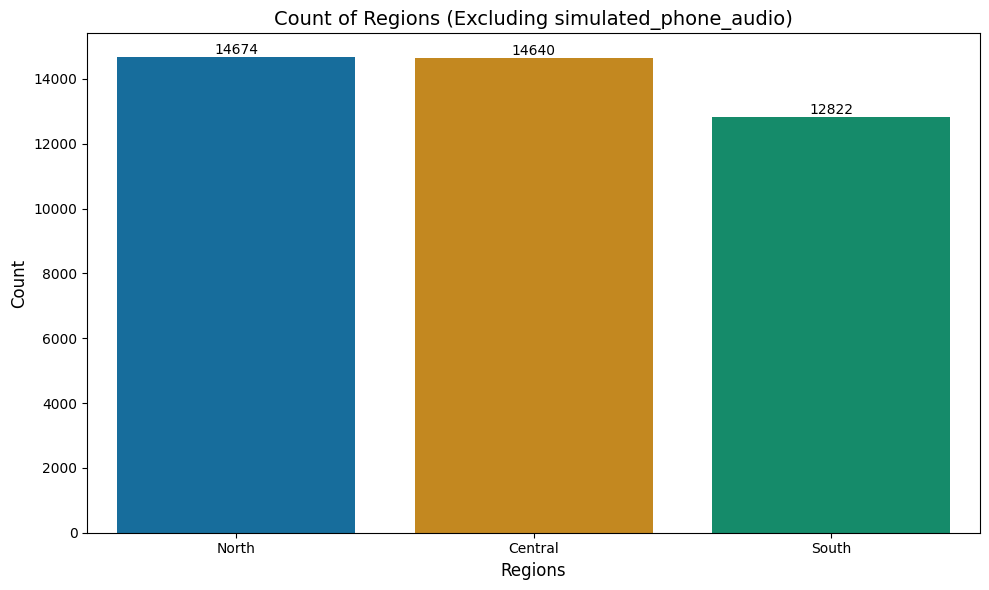

In [64]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Đường dẫn tới thư mục chứa tập dữ liệu
path = "/kaggle/input/vietnamese-accent-3-regions/***/**/*.wav"

# Mapping RAVDESS numeric encoding to regions
region_map = {
    '1': 'North',
    '2': 'Central',
    '3': 'South',
}

# Extract region labels from filenames, exclude simulated_phone_audio
filenames = glob.glob(path, recursive=True)
regions = []
for f in filenames:
    # Loại trừ file trong thư mục có "simulated_phone_audio"
    if "simulated_phone_audio" not in f.lower():
        # Lấy ký tự đầu tiên từ tên file
        region_code = os.path.basename(f).split('-')[0]
        if region_code in region_map:
            regions.append(region_map[region_code])

# Count occurrences of each region
region_counts = Counter(regions)

# Sort regions by predefined order
region_order = ['North', 'Central', 'South']
counts = [region_counts.get(r, 0) for r in region_order]

# Print the count of each region
print("Region Counts:")
for region, count in zip(region_order, counts):
    print(f"{region}: {count}")

# Plot the region distribution
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=region_order, y=counts, palette="colorblind")

# Thêm số lượng trên mỗi cột
for bar, count in zip(bars.patches, counts):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{count}', 
              ha='center', va='bottom', fontsize=10)

plt.xlabel("Regions", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Count of Regions (Excluding simulated_phone_audio)", fontsize=14)
plt.tight_layout()

# Lưu biểu đồ
plt.savefig("/kaggle/working/region_counts.png", dpi=300, bbox_inches='tight')
print("Saved chart to /kaggle/working/region_counts.png")

plt.show()

region Counts:
Male: 26155
Female: 15981


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


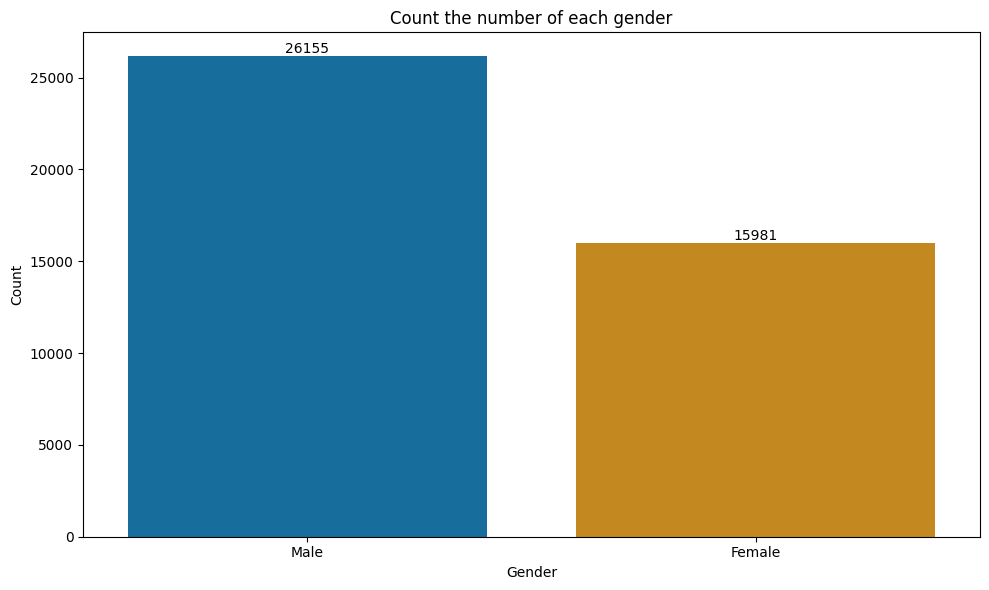

In [65]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Đường dẫn tới thư mục chứa tập dữ liệu
path = "/kaggle/input/vietnamese-accent-3-regions/***/**/*.wav"

# Mapping RAVDESS numeric encoding to regions
Gender_map = {
    '0': 'Male',
    '1': 'Female'
}

# Extract region labels from filenames, exclude simulated_phone_audio
filenames = glob.glob(path, recursive=True)
genders = []
for f in filenames:
    # Loại trừ file trong thư mục có "simulated_phone_audio"
    if "simulated_phone_audio" not in f.lower():
        # Lấy ký tự đầu tiên từ tên file
        gender_code = os.path.basename(f).split('-')[2]
        if gender_code in Gender_map:
            genders.append(Gender_map[gender_code])

# Count occurrences of each region
genders_counts = Counter(genders)

# Sort regions by predefined order
Gender_order = ['Male','Female']
counts = [genders_counts[g] for g in Gender_order if g in genders_counts]

# Print the count of each region
print("region Counts:")
for g in Gender_order:
    count = genders_counts.get(g, 0)
    print(f"{g}: {count}")
# Plot the region distribution
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=Gender_order, y=counts, palette="colorblind")

# Thêm số lượng trên mỗi cột
for bar, count in zip(bars.patches, counts):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{count}', 
              ha='center', va='bottom', fontsize=10)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Count the number of each gender")
plt.tight_layout()
plt.show()

In [ ]:
# Thư mục chứa file âm thanh # code cũ
audio_folder = "/kaggle/input/vietnamese-accent-3-regions"  # Cập nhật đường dẫn đúng

# Dữ liệu huấn luyện
X_path = []
X = []  # input
y_region = []  # label
y_gender = []
# Duyệt qua tất cả các file trong thư mục
for root, dirs, files in os.walk(audio_folder):
    if "simulated_phone_audio" in root.lower():
        continue
    for filename in files:
        if filename.endswith(".wav"):
            file_path = os.path.join(root, filename)
            
            # Tải âm thanh
            data, sampling_rate = librosa.load(file_path, sr=48000)
            data = match_loudness(data)
            data = normalize_audio(data)
            
            # Trích xuất đặc trưng
            features = extract_features(data, sampling_rate)
            
            # Lấy nhãn từ tên file (số thứ 3 trong tên file)
            label_region = filename.split("-")[0]  # Lấy phần tử thứ 3 (index 2)
            label_gender = filename.split("-")[2]
            # Chọn mẫu đầu tiên để in ra biểu đồ 
            # Lưu vào danh sách
            X.append(features)
            y_region.append(label_region)
            y_gender.append(label_gender)
            X_path.append(file_path)
# Chuyển X thành DataFrame
feature_names = [f"mfcc_{i}" for i in range(40)] + \
                [f"chroma_{i}" for i in range(12)] + \
                ["spectral_centroid", "spectral_bandwidth"]
features_df = pd.DataFrame(X_path, columns=['path'])
features_df[feature_names] = X
features_df['region'] = y_region
features_df['gender'] = y_gender

# Lưu thành CSV
features_df.to_csv("SRR_SGR_Dataset_update.csv", index=False)
print("✅ Feature extraction completed and saved to audio_features.csv.")

In [70]:
# Thư mục chứa file âm thanh
# Danh sách thư mục được duyệt
audio_folder = "/kaggle/input/vietnamese-accent-3-regions"


# Dữ liệu huấn luyện
X_path = []
X = []  # input
y_region = []  # label
y_gender = []
# Duyệt qua tất cả các file trong thư mục
for root, dirs, files in os.walk(audio_folder):
    for filename in files:
        if filename.endswith(".wav"):
            file_path = os.path.join(root, filename)
            
            # Tải âm thanh
            data, sampling_rate = librosa.load(file_path, sr=48000)
            data = match_loudness(data)
            data = normalize_audio(data)
            
            # Trích xuất đặc trưng
            features = extract_features(data, sampling_rate)
            
            # Lấy nhãn từ tên file (số thứ 3 trong tên file)
            label_region = filename.split("-")[0]  # Lấy phần tử thứ 3 (index 2)
            label_gender = filename.split("-")[2]
            # Chọn mẫu đầu tiên để in ra biểu đồ 
            # Lưu vào danh sách
            X.append(features)
            y_region.append(label_region)
            y_gender.append(label_gender)
            X_path.append(file_path)
# Chuyển X thành DataFrame
feature_names = [f"mfcc_{i}" for i in range(40)] + \
                [f"chroma_{i}" for i in range(12)] + \
                ["spectral_centroid", "spectral_bandwidth"]
features_df = pd.DataFrame(X_path, columns=['path'])
features_df[feature_names] = X
features_df['region'] = y_region
features_df['gender'] = y_gender

# Lưu thành CSV
features_df.to_csv("SRR_SGR_Dataset_update.csv", index=False)
print("✅ Feature extraction completed and saved to audio_features.csv.")

✅ Feature extraction completed and saved to audio_features.csv.


# Split Dataset

In [132]:
import pandas as pd

# Đọc dữ liệu
file_path = '/kaggle/input/srr-sgrfix/SRR_SGR_Dataset_update.csv'  # Thay bằng đường dẫn file của bạn
df = pd.read_csv(file_path)
speaker_val = [
    'Se chỉ luồn kim. NSND Lê Dung - Người hát dân ca hay nhất - Thi Âm nhạc Quốc tế Tchaikovsky lần 7',
    'Trống Cơm - Thương Huyền _Thu thanh trước 1975_ _ Official Lyric Video by Hà Nội Vi Vu',
    'Lý cây đa - Kim Oanh - Dân Ca Quan Họ Bắc Ninh',
    'Ca Trù Hồng Hồng Tuyết Tuyết - Kim Luyến _Official_',
    'Hội anh em hài miền Bắc thi ca nhớ về QUÊ NHÀ _ Gặp nhau cuối tuần _ Phim hài VTV hay',

    'Ca Huế_ Tương Tư Khúc - Dạ Lê',
    'NGHỀ RÈN Ở HUẾ',
    'Huế Xưa - Ngô Quốc Linh',
    'Người Huế trong nhịp sống hiện đại',

    'An Giang 2024 - Những sự kiện nổi bật _ Đài Truyền hình An Giang',
    'Dạ cổ hoài lang - Bích Phượng ca _ Đờn ca tài tử _Vietnamese traditional music',
    'Mười Thương Làng Xóm Quê Mình _Theo Điệu Nói Thơ Bạc Liêu_ - Bích Phượng ca',
    'LÝ KÉO CHÀI - Huybothai x Cao Bá Hưng _ OST Thỏ Bảy Màu và Chiến Tranh Cầu Cá _ Lyric Video',
    'Tháng Năm Không Quên - H2K x KN _OFFICIAL MV_  _ RV Underground',
    'Hành Lang Cũ _Hạ Nhớ_ - Long Nón Lá x Masew',
    'CON TRAI CƯNG _Piano Version_ _ ICM x B Ray _ MV Official',
    'Đồi Thông Hai Mộ - Phương Anh _ Official MV'
]

speaker_test = [
    'BÈO DẠT MÂY TRÔI x CÒ LẢ x TRỐNG CƠM _ Tốp ca nam nhà hát dân ca QHBN _ La Cà Hát Ca _9',
    'Bản Tin Thời Sự Trưa 8_3 _ Cập Nhật Tin Tức Mới Nhất Trong Ngày _ BTVv',
    
    'Lý Ngựa Ô Huế _Ly horse umbrella Hue_ - Quang Linh',
    'CREATIVE TOURISM - Nhịp cầu tuổi trẻ',
    'Chuyện Huế_ Miền gái đẹp Kim Long',
    'Ca Huế_  Tứ Đại Cảnh - lời cổ -  NS Kim Liên',
    
    'Dự báo thời tiết Tiền Giang ngày 31.03.2023 _ THTG',
    'Dự báo thời tiết_ Sài Gòn và cả Nam Bộ bước vào mùa nắng nóng nhất trong năm',
    'ÁO SỜN VAI _ Hồ Khắc Tùng _ St_Đậm Nguyễn_ Người có còn thương thương dùm tôi manh áo dãi dầu…',
    'BTV Việt Phong nói giọng miền Nam - Tin tức 14h trên kênh VTV1 _10_2015_',
    'Nóng Sài Gòn_ Thông tin mới liên quan vụ án Trương Mỹ Lan_ Báo Lao Động',
    'Duyên Phận _ Dương Hồng Loan',
    'Dự báo thời tiết TP. Cần Thơ sáng 19_2_2025 _ THTPCT'
]
# U:Update
train_df_U = df[df['path'].apply(lambda x: (x.split('/')[5] not in speaker_val) and (x.split('/')[5] not in speaker_test))]
val_df_U  = df[df['path'].apply(lambda x: x.split('/')[5] in speaker_val)]
test_df_U  = df[df['path'].apply(lambda x: x.split('/')[5] in speaker_test)]

print(f"Train set: {len(train_df_U )} samples")
print(f"Validation set: {len(val_df_U )} samples")
print(f"Test set: {len(test_df_U )} samples")

val_df_U

Train set: 28349 samples
Validation set: 7690 samples
Test set: 6097 samples


,path,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,spectral_centroid,spectral_bandwidth,region,gender
1095,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-211.523712,121.455879,-18.062420,57.965229,-18.440161,11.567593,-4.564446,-22.697426,-4.433876,...,0.121587,0.148324,0.246172,0.378647,0.385284,0.431021,2527.791629,3041.988039,1,0
1096,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-112.664207,144.145660,-54.211098,22.841881,-44.954918,6.516815,-13.418956,-14.532351,-7.298872,...,0.211370,0.308823,0.451098,0.672794,0.508573,0.279705,2684.281603,3011.936118,1,0
1097,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-227.487534,134.619522,-11.284151,15.399792,-45.050938,-18.427237,-8.816059,-15.831711,-10.035702,...,0.055251,0.102095,0.174059,0.455716,0.381895,0.154082,1954.902521,2648.528075,1,0
1098,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-76.595184,148.449692,-67.793190,28.779737,-52.323418,8.946646,-11.121984,-4.181762,2.884864,...,0.363942,0.295755,0.303263,0.323400,0.284280,0.264849,2984.222235,2994.656896,1,0
1099,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-187.585541,153.017761,-17.891350,9.693112,-39.681778,-4.901712,-10.217187,-8.710388,5.279803,...,0.297543,0.284644,0.414354,0.427673,0.383368,0.325503,2189.444180,2799.395886,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41045,/kaggle/input/vietnamese-accent-3-regions/Sout...,-172.942215,149.607941,-24.562366,46.884407,-13.507683,19.979942,-14.409205,-3.950812,-2.081148,...,0.365732,0.310310,0.374430,0.381694,0.455313,0.480522,2562.141536,3118.705104,3,0
41046,/kaggle/input/vietnamese-accent-3-regions/Sout...,-238.594803,128.292862,-1.927609,57.556465,-5.226180,14.367365,-16.734842,-3.211302,-2.036071,...,0.422626,0.388650,0.405768,0.365655,0.278203,0.223568,2916.612068,3379.391641,3,1
41047,/kaggle/input/vietnamese-accent-3-regions/Sout...,-168.935944,133.481598,-22.284430,44.542610,-22.614208,13.562967,-28.405008,-12.853199,-2.613192,...,0.418779,0.467412,0.511214,0.434663,0.296386,0.259400,3068.380558,3218.223308,3,1
41048,/kaggle/input/vietnamese-accent-3-regions/Sout...,-159.660080,143.032715,-18.705278,45.888451,-21.550568,12.666612,-14.825770,-1.206388,-0.552799,...,0.438647,0.380603,0.313055,0.345754,0.327091,0.328827,2800.838277,3264.109410,3,0


In [133]:
train_df_U 

,path,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,spectral_centroid,spectral_bandwidth,region,gender
0,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-152.109039,169.960861,-58.232513,25.386854,-15.295058,-4.153309,-21.245150,-12.667172,1.127992,...,0.172337,0.145420,0.177730,0.114517,0.147734,0.194205,2204.226413,2361.643893,1,0
1,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-196.210419,111.555321,-26.475689,74.043022,-20.183586,-6.558244,-34.211658,-5.121706,4.061919,...,0.294344,0.244825,0.227219,0.197955,0.341069,0.628654,2934.203454,3092.587660,1,0
2,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-263.292206,146.503403,-20.056776,34.973209,3.420864,-1.526007,-27.649923,-12.394529,0.021041,...,0.197209,0.257870,0.306613,0.291127,0.404372,0.569240,1794.162716,2590.181470,1,0
3,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-210.880783,155.848679,-44.135548,10.337218,-15.551709,-5.601216,-16.924978,-3.302175,7.972327,...,0.315250,0.373403,0.316998,0.199470,0.231634,0.344497,2060.498973,2348.720504,1,0
4,/kaggle/input/vietnamese-accent-3-regions/(-1)...,-250.762527,164.467026,29.967960,41.181156,-6.958894,8.183934,-29.179569,11.234446,6.597400,...,0.343428,0.191311,0.211466,0.219814,0.346824,0.492638,1615.329188,2940.761813,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42096,/kaggle/input/vietnamese-accent-3-regions/Sout...,-46.313427,145.186371,-50.040203,58.475689,-33.911346,41.900135,-27.981350,25.883535,-0.728638,...,0.628547,0.528361,0.440574,0.460083,0.431557,0.390472,3714.200272,3917.150940,3,0
42097,/kaggle/input/vietnamese-accent-3-regions/Sout...,-79.320877,134.730774,-31.710072,65.972824,-26.958111,45.472191,-16.520325,17.891865,8.912357,...,0.644133,0.639236,0.703247,0.778632,0.646974,0.497139,3459.326148,3926.140164,3,0
42098,/kaggle/input/vietnamese-accent-3-regions/Sout...,-79.515594,152.847153,-44.715462,62.072994,-27.293167,51.870777,-32.211021,14.386619,4.628279,...,0.460662,0.378113,0.361345,0.386097,0.354277,0.352558,3471.423382,3726.451974,3,0
42099,/kaggle/input/vietnamese-accent-3-regions/Sout...,-56.928745,143.034470,-46.165043,55.094669,-27.756763,43.342201,-25.678089,22.037155,-2.685605,...,0.454511,0.499039,0.474007,0.447395,0.449062,0.470020,3627.257787,3909.920422,3,0


In [134]:
Xr_train = train_df_U.copy().iloc[:,1:-2].values
Xr_dev = val_df_U.copy().iloc[:,1:-2].values
Xr_test = test_df.copy().iloc[:,1:-2].values

yr_train = train_df_U.copy()['region'].values
yr_dev = val_df_U.copy()['region'].values
yr_test = test_df_U.copy()['region'].values

Xg_train = train_df_U.copy().iloc[:,1:-2].values
Xg_dev = val_df_U.copy().iloc[:,1:-2].values
Xg_test = test_df_U.copy().iloc[:,1:-2].values

yg_train = train_df_U.copy()['gender'].values
yg_dev = val_df_U.copy()['gender'].values
yg_test = test_df_U.copy()['gender'].values



In [ ]:
# Miền Bắc bị lệch giới tính nam 2128, nữ có 729 nên không thể dùng code này được.

# import pandas as pd
# import numpy as np

# # Hàm thêm nhiễu vào đặc trưng
# def add_noise_to_features(features, noise_factor=0.005):
#     noise = np.random.randn(len(features)) * noise_factor
#     augmented_features = features + noise
#     return augmented_features

# # Đọc dữ liệu từ file CSV
# data = pd.read_csv('/kaggle/working/SRR_SGR_Dataset.csv')  # Thay bằng đường dẫn file CSV của bạn

# # Danh sách các cột đặc trưng
# feature_cols = [f'mfcc_{i}' for i in range(40)] + [f'chroma_{i}' for i in range(12)] + \
#                ['spectral_centroid', 'spectral_bandwidth']

# # Tạo cột tổ hợp region-gender
# data['region_gender'] = data['region'].astype(str) + '_' + data['gender'].astype(str)

# # Đếm số mẫu theo tổ hợp
# combo_counts = data['region_gender'].value_counts()
# print("Số mẫu ban đầu theo tổ hợp region_gender:")
# print(combo_counts)

# # Xác định lớp A (tổ hợp ít nhất) và target
# class_min_combo = combo_counts.idxmin()
# min_count_combo = combo_counts.min()
# target_count_combo = max(min_count_combo * 2, 10)  # Nhân đôi hoặc ít nhất 10 mẫu mỗi tổ hợp

# print(f"\nLớp A (tổ hợp): {class_min_combo} với {min_count_combo} mẫu, target cho mỗi tổ hợp là {target_count_combo} mẫu.")

# # --- Xử lý cho cả SRR_data và SGR_data ---
# for output_file, drop_cols in [('SRR_data.csv', ['path', 'gender']), ('SGR_data.csv', ['path', 'region'])]:
#     # Loại bỏ cột không cần thiết
#     working_data = data.drop(columns=drop_cols)
    
#     # Danh sách để lưu dữ liệu tăng cường
#     augmented_data = []
    
#     # Xử lý từng tổ hợp
#     for combo in combo_counts.index:
#         region, gender = map(int, combo.split('_'))
#         class_df = data[data['region_gender'] == combo]
#         current_count = len(class_df)
        
#         # Tính số mẫu cần augment
#         augment_count = target_count_combo - current_count
        
#         print(f"\nXử lý tổ hợp {combo}:")
#         print(f"  Số mẫu hiện tại: {current_count}")
#         print(f"  Số mẫu cần augment: {augment_count}")
        
#         # Lấy mẫu ngẫu nhiên để augment
#         augment_samples = class_df.sample(n=augment_count, replace=True) if augment_count > 0 else pd.DataFrame()
        
#         # Thêm nhiễu vào đặc trưng
#         for idx, row in augment_samples.iterrows():
#             features = row[feature_cols].values.astype(np.float32)
#             augmented_features = add_noise_to_features(features)
#             augmented_row = {col: val for col, val in zip(feature_cols, augmented_features)}
#             augmented_row['region'] = region
#             augmented_row['gender'] = gender
#             augmented_data.append(augmented_row)
    
#     # Gộp dữ liệu gốc và dữ liệu tăng cường
#     augmented_df = pd.DataFrame(augmented_data)
#     final_df = pd.concat([working_data.drop(columns=['region_gender']), augmented_df], ignore_index=True)
    
#     # Lưu file
#     final_df.to_csv(output_file, index=False)
#     print(f"\nSố mẫu sau khi augment trong {output_file}:")
#     print(final_df.groupby(['region', 'gender']).size())


# Prepare 2D data for CNN Model

In [74]:
!pip install keras-tuner
!pip install scikit-learn==1.2.2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU, Dropout, Input, Activation, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
print("Phiên bản scikit-learn:", sklearn.__version__)

Phiên bản scikit-learn: 1.2.2


Phiên bản scikit-learn: 1.2.2


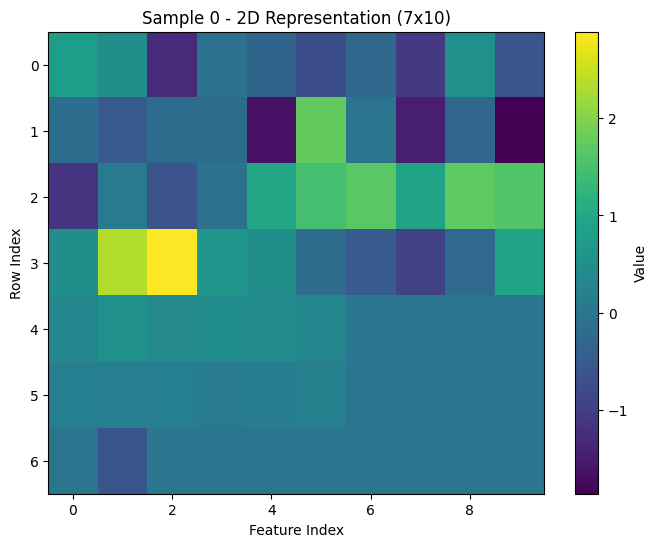

Sample values:
 [[ 0.79210697  0.47850796 -1.303594   -0.09106417 -0.33874634 -0.7204614
  -0.26493843 -1.08104813  0.51836424 -0.61146199]
 [-0.15224139 -0.52194283 -0.19087992 -0.18111885 -1.62829803  1.74833235
  -0.0370059  -1.45855814 -0.29551171 -1.86609744]
 [-1.15054512  0.06978765 -0.65372221 -0.08474203  0.946583    1.49018255
   1.67904703  0.91032032  1.7187058   1.60568303]
 [ 0.50823154  2.34684973  2.89175039  0.62279614  0.48546987 -0.16149187
  -0.50069692 -0.94959503 -0.24572936  0.906363  ]
 [ 0.33929484  0.52109462  0.37825063  0.45200656  0.42382512  0.3205396
   0.          0.          0.          0.        ]
 [ 0.18372771  0.16341597  0.18397006  0.11060106  0.14381771  0.20390933
   0.          0.          0.          0.        ]
 [-0.02408145 -0.60685814  0.          0.          0.          0.
   0.          0.          0.          0.        ]]
28349


In [136]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib
import sklearn
print("Phiên bản scikit-learn:", sklearn.__version__)

# Hàm chuyển sang 2D
def convert_1dto2d(input_1d):
    num_samples = input_1d.shape[0]
    output_2d = np.zeros((num_samples, 7, 10, 1))
    for i in range(num_samples):
        mfcc = input_1d[i, :40].reshape(4, 10)
        chroma = input_1d[i, 40:52].reshape(2, 6)
        spectral = input_1d[i, 52:54].reshape(1, 2)
        chroma_padded = np.pad(chroma, ((0, 0), (0, 4)), mode='constant')
        spectral_padded = np.pad(spectral, ((0, 0), (0, 8)), mode='constant')
        matrix_2d = np.vstack((mfcc, chroma_padded, spectral_padded))
        output_2d[i] = matrix_2d[..., np.newaxis]
    return output_2d


def make2dData( X_train, X_dev, X_test, name):
    
    scaler_mfcc = StandardScaler()
    scaler_chroma = MinMaxScaler()
    scaler_spectral = StandardScaler()
    
    # Chỉ fit trên tập train
    X_train_mfcc = scaler_mfcc.fit_transform(X_train[:, :40])
    X_train_chroma = scaler_chroma.fit_transform(X_train[:, 40:52])
    X_train_spectral = scaler_spectral.fit_transform(X_train[:, 52:54])
    
    X_dev_mfcc = scaler_mfcc.transform(X_dev[:, :40])
    X_dev_chroma = scaler_chroma.transform(X_dev[:, 40:52])
    X_dev_spectral = scaler_spectral.transform(X_dev[:, 52:54])
    
    X_test_mfcc = scaler_mfcc.transform(X_test[:, :40])
    X_test_chroma = scaler_chroma.transform(X_test[:, 40:52])
    X_test_spectral = scaler_spectral.transform(X_test[:, 52:54])

    # Lưu lại scaler để dùng cho dữ liệu thực tế sau này
    joblib.dump(scaler_mfcc, f"scaler_mfcc_{name}.pkl")
    joblib.dump(scaler_chroma, f"scaler_chroma_{name}.pkl")
    joblib.dump(scaler_spectral, f"scaler_spectral_{name}.pkl")
    
    # Gộp lại sau khi scale
    X_train_scaled = np.hstack((X_train_mfcc, X_train_chroma, X_train_spectral))
    X_dev_scaled = np.hstack((X_dev_mfcc, X_dev_chroma, X_dev_spectral))
    X_test_scaled = np.hstack((X_test_mfcc, X_test_chroma, X_test_spectral))
    
    X_train_2D = convert_1dto2d(X_train_scaled)
    X_dev_2D = convert_1dto2d(X_dev_scaled)
    X_test_2D = convert_1dto2d(X_test_scaled)
    
    
    return X_train_2D, X_dev_2D, X_test_2D


Xr_train_2D, Xr_dev_2D, Xr_test_2D = make2dData(Xr_train, Xr_dev, Xr_test, 'reg-update')
Xg_train_2D, Xg_dev_2D, Xg_test_2D = make2dData(Xg_train, Xg_dev, Xg_test, 'gen-update')

# Trực quan hóa một mẫu
sample_index = 0  # Chọn mẫu đầu tiên
sample = Xr_train_2D[sample_index, :, :, 0]  # Lấy dữ liệu 2D (7x10)

plt.figure(figsize=(8, 6))
plt.imshow(sample, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title(f'Sample {sample_index} - 2D Representation (7x10)')
plt.xlabel('Feature Index')
plt.ylabel('Row Index')
plt.show()

print("Sample values:\n", sample)

In [127]:

yr_train_cat = tf.keras.utils.to_categorical(yr_train -1, 3)  
yr_dev_cat = tf.keras.utils.to_categorical(yr_dev -1, 3)
yr_test_cat = tf.keras.utils.to_categorical(yr_test -1, 3)

yg_train_cat = tf.keras.utils.to_categorical(yg_train, 2) 
yg_dev_cat = tf.keras.utils.to_categorical(yg_dev, 2)
yg_test_cat = tf.keras.utils.to_categorical(yg_test, 2)

## Initialize Callbacks and Evaluate function (above)

# Model

In [77]:
# U, its mean Update.

CNN2DRegionU = Sequential()

# First Conv2D layer
CNN2DRegionU.add(Conv2D(
    filters=96,  # filters_0
    kernel_size=5,  # kernel_size_0
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(7, 10, 1),
    kernel_regularizer=l2(0.008732453502912857)  # l2_conv_0
))
CNN2DRegionU.add(BatchNormalization())
CNN2DRegionU.add(MaxPooling2D(
    pool_size=2,  # pool_size_0
    strides=1,  # pool_strides_0
    padding='same'
))

# Second Conv2D layer
CNN2DRegionU.add(Conv2D(
    filters=64,  # filters_1
    kernel_size=5,  # kernel_size_1
    strides=1,
    padding='same',
    activation='relu',
    kernel_regularizer=l2(0.0008307655913624025)  # l2_conv_1
))
CNN2DRegionU.add(BatchNormalization())

# Dropout after Conv2D layers
CNN2DRegionU.add(Dropout(rate=0.2))  # dropout_conv

# Flatten layer
CNN2DRegionU.add(Flatten())

# First Dense layer
CNN2DRegionU.add(Dense(
    units=96,  # units_0
    activation='relu',
    kernel_regularizer=l2(0.00036558483095598383)  # l2_dense_0
))
CNN2DRegionU.add(BatchNormalization())
CNN2DRegionU.add(Dropout(rate=0.3))  # dropout_dense_0

# Second Dense layer
CNN2DRegionU.add(Dense(
    units=16,  # units_1
    activation='relu',
    kernel_regularizer=l2(0.0001129701550594694)  # l2_dense_1
))
CNN2DRegionU.add(BatchNormalization())
CNN2DRegionU.add(Dropout(rate=0.2))  # dropout_dense_1

# Output layer
CNN2DRegionU.add(Dense(3, activation='softmax'))

# Compile the model
CNN2DRegionU.compile(
    optimizer=Adam(learning_rate=0.00021682255492865924),  # learning_rate 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
CNN2DRegionU.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 7, 10, 96)           │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 7, 10, 96)           │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 7, 10, 96)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 7, 10, 64)           │         153,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 7, 10, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 7, 10, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 4480)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 96)                  │         430,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 16)                  │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 589,027 (2.25 MB)

 Trainable params: 588,483 (2.24 MB)

 Non-trainable params: 544 (2.12 KB)

In [78]:
CNN2DGenderU = Sequential()

# First Conv2D layer
CNN2DGenderU.add(Conv2D(
    filters=96,  # filters_0
    kernel_size=5,  # kernel_size_0
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(7, 10, 1),
    kernel_regularizer=l2(0.008732453502912857)  # l2_conv_0
))
CNN2DGenderU.add(BatchNormalization())
CNN2DGenderU.add(MaxPooling2D(
    pool_size=2,  # pool_size_0
    strides=1,  # pool_strides_0
    padding='same'
))

# Second Conv2D layer
CNN2DGenderU.add(Conv2D(
    filters=64,  # filters_1
    kernel_size=5,  # kernel_size_1
    strides=1,
    padding='same',
    activation='relu',
    kernel_regularizer=l2(0.0008307655913624025)  # l2_conv_1
))
CNN2DGenderU.add(BatchNormalization())

# Dropout after Conv2D layers
CNN2DGenderU.add(Dropout(rate=0.2))  # dropout_conv

# Flatten layer
CNN2DGenderU.add(Flatten())

# First Dense layer
CNN2DGenderU.add(Dense(
    units=96,  # units_0
    activation='relu',
    kernel_regularizer=l2(0.00036558483095598383)  # l2_dense_0
))
CNN2DGenderU.add(BatchNormalization())
CNN2DGenderU.add(Dropout(rate=0.3))  # dropout_dense_0

# Second Dense layer
CNN2DGenderU.add(Dense(
    units=16,  # units_1
    activation='relu',
    kernel_regularizer=l2(0.0001129701550594694)  # l2_dense_1
))
CNN2DGenderU.add(BatchNormalization())
CNN2DGenderU.add(Dropout(rate=0.2))  # dropout_dense_1

# Output layer
CNN2DGenderU.add(Dense(2, activation='softmax'))

# Compile the model
CNN2DGenderU.compile(
    optimizer=Adam(learning_rate=0.00021682255492865924),  # learning_rate 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
CNN2DGenderU.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 7, 10, 96)           │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 7, 10, 96)           │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 7, 10, 96)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 7, 10, 64)           │         153,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 7, 10, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 7, 10, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 4480)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 96)                  │         430,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 16)                  │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_23               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 589,010 (2.25 MB)

 Trainable params: 588,466 (2.24 MB)

 Non-trainable params: 544 (2.12 KB)

In [79]:
lr_reducer, checkpoint, early_stopping = Callbacks('CNN2DRegionU')
# Huấn luyện
historyCNN2DRegionU = CNN2DRegionU.fit(
    Xr_train_2D,  # Dữ liệu huấn luyện tăng cường
    yr_train_cat,  # Nhãn huấn luyện dạng one-hot
    epochs=200, 
    batch_size=64,  
    validation_data=(Xr_dev_2D, yr_dev_cat),  # Dữ liệu validation
    callbacks=[lr_reducer, checkpoint, early_stopping],  # Sử dụng các callback
    verbose=1  # Hiển thị tiến trình huấn luyện
)

Epoch 1/200
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7107 - loss: 0.8693
Epoch 1: val_accuracy improved from -inf to 0.32380, saving model to best_CNN2DRegionU.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7110 - loss: 0.8688 - val_accuracy: 0.3238 - val_loss: 1.7753 - learning_rate: 2.1682e-04
Epoch 2/200
436/443 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9254 - loss: 0.3785
Epoch 2: val_accuracy improved from 0.32380 to 0.36593, saving model to best_CNN2DRegionU.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9255 - loss: 0.3782 - val_accuracy: 0.3659 - val_loss: 2.3671 - learning_rate: 2.1682e-04
Epoch 3/200
437/443 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9560 - loss: 0.2917
Epoch 3: val_accuracy improved from 0.36593 to 0.36814, saving model to best_CNN2DRegionU.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9560 - loss: 0.2916 - val_accuracy: 0.3681 - val_loss: 2.5149 - learning_rate: 2.1682e-04
Epoch 4/200
431/

In [80]:
lr_reducer, checkpoint, early_stopping = Callbacks('CNN2DGenderU')
# Huấn luyện
historyCNN2DGenderU = CNN2DGenderU.fit(
    Xg_train_2D,  # Dữ liệu huấn luyện tăng cường
    yg_train_cat,  # Nhãn huấn luyện dạng one-hot
    epochs=200, 
    batch_size=64,  
    validation_data=(Xg_dev_2D, yg_dev_cat),  # Dữ liệu validation
    callbacks=[lr_reducer, checkpoint, early_stopping],  # Sử dụng các callback
    verbose=1  # Hiển thị tiến trình huấn luyện
)

Epoch 1/200
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8438 - loss: 0.5174
Epoch 1: val_accuracy improved from -inf to 0.68466, saving model to best_CNN2DGenderU.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8439 - loss: 0.5172 - val_accuracy: 0.6847 - val_loss: 0.8348 - learning_rate: 2.1682e-04
Epoch 2/200
440/443 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9689 - loss: 0.2456
Epoch 2: val_accuracy improved from 0.68466 to 0.72393, saving model to best_CNN2DGenderU.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9690 - loss: 0.2455 - val_accuracy: 0.7239 - val_loss: 0.8941 - learning_rate: 2.1682e-04
Epoch 3/200
428/443 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.1985
Epoch 3: val_accuracy improved from 0.72393 to 0.74473, saving model to best_CNN2DGenderU.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9833 - loss: 0.1985 - val_accuracy: 0.7447 - val_loss: 0.8961 - learning_rate: 2.1682e-04
Epoch 4/200
439/

In [81]:
CNN2DGender.summary()
CNN2DRegion.summary()
CNN2DGender.save('gender_model_normal_update.keras')
CNN2DRegion.save('region_model_normal_update.keras')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 7, 10, 96)           │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 7, 10, 96)           │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 10, 96)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 7, 10, 64)           │         153,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 7, 10, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 7, 10, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 4480)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 96)                  │         430,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,765,944 (6.74 MB)

 Trainable params: 588,466 (2.24 MB)

 Non-trainable params: 544 (2.12 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 7, 10, 96)           │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 7, 10, 96)           │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 10, 96)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 10, 64)           │         153,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 7, 10, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 7, 10, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4480)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 96)                  │         430,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,765,995 (6.74 MB)

 Trainable params: 588,483 (2.24 MB)

 Non-trainable params: 544 (2.12 KB)

 Optimizer params: 1,176,968 (4.49 MB)

191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5082 - loss: 2.2547


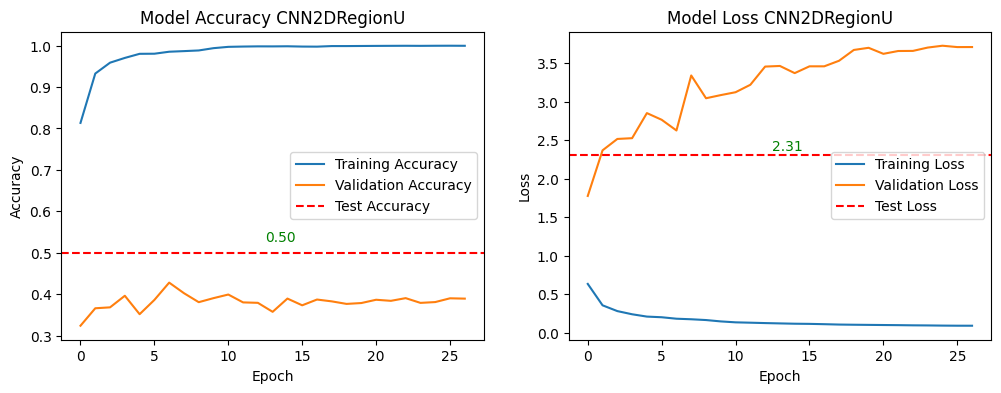

<Figure size 640x480 with 0 Axes>

191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8978 - loss: 0.5659


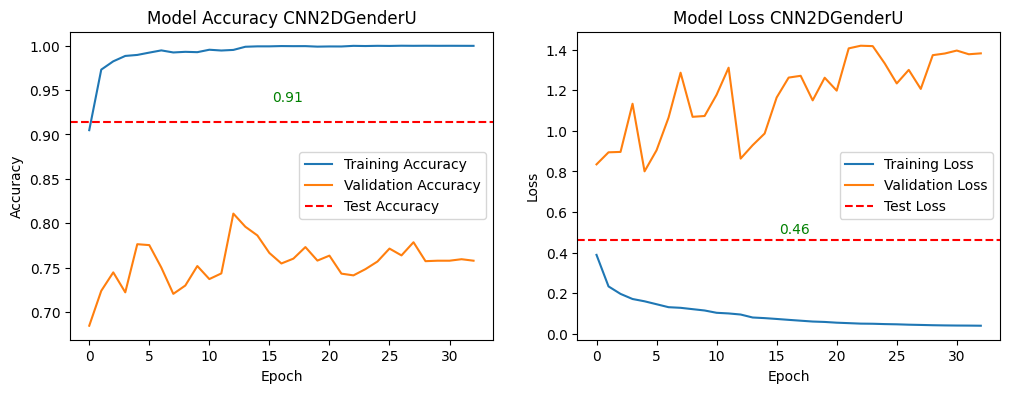

<Figure size 640x480 with 0 Axes>

In [82]:
Evaluateandlogperformance(CNN2DRegionU, historyCNN2DRegionU, Xr_test_2D, yr_test_cat, 'CNN2DRegionU', detail = False)
Evaluateandlogperformance(CNN2DGenderU, historyCNN2DGenderU, Xg_test_2D, yg_test_cat, 'CNN2DGenderU', detail = False)


191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


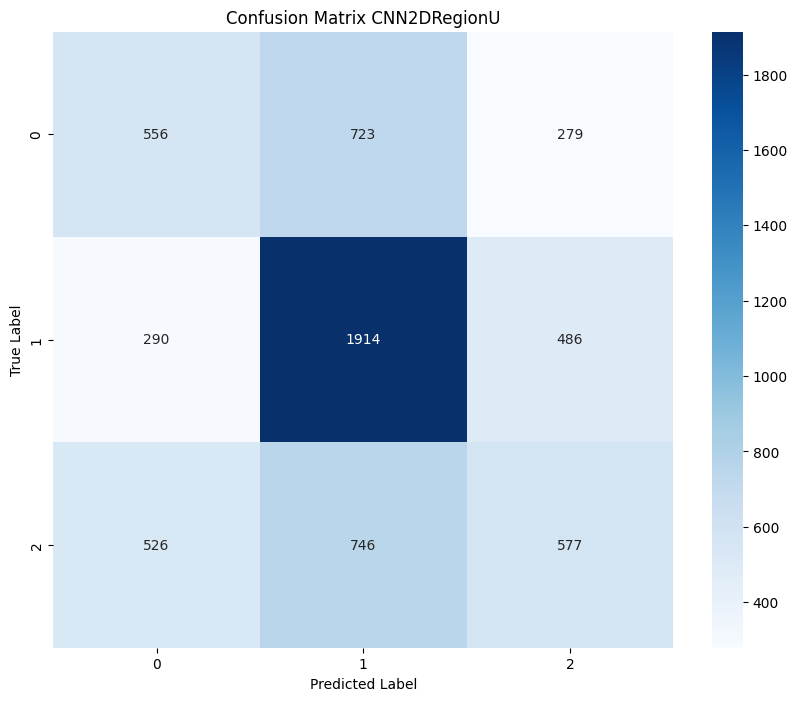


Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.36      0.38      1558
           1       0.57      0.71      0.63      2690
           2       0.43      0.31      0.36      1849

    accuracy                           0.50      6097
   macro avg       0.47      0.46      0.46      6097
weighted avg       0.48      0.50      0.48      6097


Detailed Metrics by Class:

Class 0:
Precision: 0.4052
Recall: 0.3569
F1-score: 0.3795

Class 1:
Precision: 0.5658
Recall: 0.7115
F1-score: 0.6303

Class 2:
Precision: 0.4300
Recall: 0.3121
F1-score: 0.3616

Overall Metrics:
Average Precision: 0.4836
Average Recall: 0.4998
Average F1-score: 0.4848
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


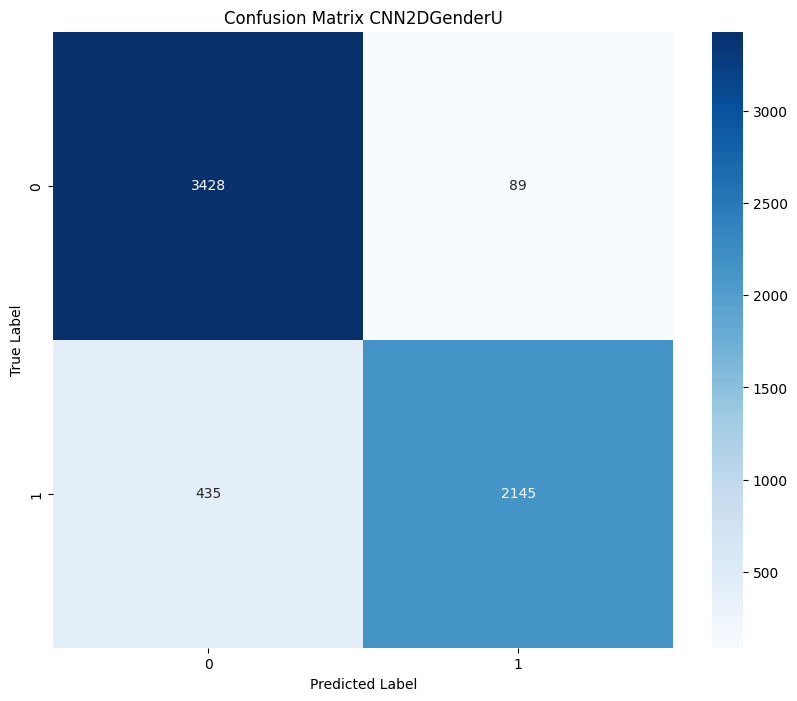


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3517
           1       0.96      0.83      0.89      2580

    accuracy                           0.91      6097
   macro avg       0.92      0.90      0.91      6097
weighted avg       0.92      0.91      0.91      6097


Detailed Metrics by Class:

Class 0:
Precision: 0.8874
Recall: 0.9747
F1-score: 0.9290

Class 1:
Precision: 0.9602
Recall: 0.8314
F1-score: 0.8912

Overall Metrics:
Average Precision: 0.9182
Average Recall: 0.9141
Average F1-score: 0.9130


In [84]:
compute_confusion_matrix(CNN2DRegionU, Xr_test_2D, yr_test_cat, 'CNN2DRegionU', 3)
compute_confusion_matrix(CNN2DGenderU, Xg_test_2D, yg_test_cat, 'CNN2DGenderU', 2)

# Keras Tuner 2

In [85]:
# Hàm xây dựng mô hình với Keras Tuner
def build_region(hp):
    model = Sequential()

    # First Conv2D layer
    filters_0 = hp.Int('filters_0', min_value=16, max_value=96, step=16)
    kernel_size_0 = hp.Choice('kernel_size_0', values=[3, 5])
    l2_conv_0 = hp.Float('l2_conv_0', min_value=1e-4, max_value=1e-2, sampling='log')
    
    model.add(Conv2D(
        filters=filters_0,
        kernel_size=kernel_size_0,
        strides=1,
        padding='same',
        activation='relu',
        input_shape=(7, 10, 1),
        kernel_regularizer=l2(l2_conv_0)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(
        pool_size=hp.Choice('pool_size_0', values=[2, 3]),
        strides=1,
        padding='same'
    ))

    # Second Conv2D layer (tùy chọn)
    include_conv1 = hp.Boolean('include_conv1')
    if include_conv1:
        filters_1 = hp.Int('filters_1', min_value=16, max_value=64, step=16)
        kernel_size_1 = hp.Choice('kernel_size_1', values=[3, 5])
        l2_conv_1 = hp.Float('l2_conv_1', min_value=1e-4, max_value=1e-2, sampling='log')
        
        model.add(Conv2D(
            filters=filters_1,
            kernel_size=kernel_size_1,
            strides=1,
            padding='same',
            activation='relu',
            kernel_regularizer=l2(l2_conv_1)
        ))
        model.add(BatchNormalization())

    # Dropout sau Conv layers
    dropout_conv = hp.Float('dropout_conv', min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(rate=dropout_conv))

    # Flatten
    model.add(Flatten())

    # First Dense layer (tùy chọn)
    include_dense0 = hp.Boolean('include_dense0')
    if include_dense0:
        units_0 = hp.Int('units_0', min_value=16, max_value=96, step=16)
        l2_dense_0 = hp.Float('l2_dense_0', min_value=1e-4, max_value=1e-2, sampling='log')
        dropout_dense_0 = hp.Float('dropout_dense_0', min_value=0.0, max_value=0.5, step=0.1)
        
        model.add(Dense(
            units=units_0,
            activation='relu',
            kernel_regularizer=l2(l2_dense_0)
        ))
        model.add(BatchNormalization())
        model.add(Dropout(rate=dropout_dense_0))

    # Second Dense layer
    units_1 = hp.Int('units_1', min_value=8, max_value=32, step=8)
    l2_dense_1 = hp.Float('l2_dense_1', min_value=1e-4, max_value=1e-2, sampling='log')
    dropout_dense_1 = hp.Float('dropout_dense_1', min_value=0.0, max_value=0.5, step=0.1)
    
    model.add(Dense(
        units=units_1,
        activation='relu',
        kernel_regularizer=l2(l2_dense_1)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(rate=dropout_dense_1))

    # Output layer (3 lớp cho region)
    model.add(Dense(3, activation='softmax'))

    # Compile model
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model
    
# EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

tuner_regionU = kt.Hyperband(
    build_region,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    directory='tuner_dir2',
    project_name='cnn2d_region_hyperband'
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
# Hàm xây dựng mô hình với Keras Tuner
def build_gender(hp):
    model = Sequential()

    # First Conv2D layer
    filters_0 = hp.Int('filters_0', min_value=16, max_value=96, step=16)
    kernel_size_0 = hp.Choice('kernel_size_0', values=[3, 5])
    l2_conv_0 = hp.Float('l2_conv_0', min_value=1e-4, max_value=1e-2, sampling='log')
    
    model.add(Conv2D(
        filters=filters_0,
        kernel_size=kernel_size_0,
        strides=1,
        padding='same',
        activation='relu',
        input_shape=(7, 10, 1),
        kernel_regularizer=l2(l2_conv_0)
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(
        pool_size=hp.Choice('pool_size_0', values=[2, 3]),
        strides=1,
        padding='same'
    ))

    # Second Conv2D layer (tùy chọn)
    include_conv1 = hp.Boolean('include_conv1')
    if include_conv1:
        filters_1 = hp.Int('filters_1', min_value=16, max_value=64, step=16)
        kernel_size_1 = hp.Choice('kernel_size_1', values=[3, 5])
        l2_conv_1 = hp.Float('l2_conv_1', min_value=1e-4, max_value=1e-2, sampling='log')
        
        model.add(Conv2D(
            filters=filters_1,
            kernel_size=kernel_size_1,
            strides=1,
            padding='same',
            activation='relu',
            kernel_regularizer=l2(l2_conv_1)
        ))
        model.add(BatchNormalization())

    # Dropout sau Conv layers
    dropout_conv = hp.Float('dropout_conv', min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(rate=dropout_conv))

    # Flatten
    model.add(Flatten())

    # First Dense layer (tùy chọn)
    include_dense0 = hp.Boolean('include_dense0')
    if include_dense0:
        units_0 = hp.Int('units_0', min_value=16, max_value=96, step=16)
        l2_dense_0 = hp.Float('l2_dense_0', min_value=1e-4, max_value=1e-2, sampling='log')
        dropout_dense_0 = hp.Float('dropout_dense_0', min_value=0.0, max_value=0.5, step=0.1)
        
        model.add(Dense(
            units=units_0,
            activation='relu',
            kernel_regularizer=l2(l2_dense_0)
        ))
        model.add(BatchNormalization())
        model.add(Dropout(rate=dropout_dense_0))

    # Second Dense layer
    units_1 = hp.Int('units_1', min_value=8, max_value=32, step=8)
    l2_dense_1 = hp.Float('l2_dense_1', min_value=1e-4, max_value=1e-2, sampling='log')
    dropout_dense_1 = hp.Float('dropout_dense_1', min_value=0.0, max_value=0.5, step=0.1)
    
    model.add(Dense(
        units=units_1,
        activation='relu',
        kernel_regularizer=l2(l2_dense_1)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(rate=dropout_dense_1))

    # Output layer (3 lớp cho region)
    model.add(Dense(2, activation='softmax'))

    # Compile model
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


# EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

tuner_genderU = kt.Hyperband(
    build_gender,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    directory='tuner_dir2',
    project_name='cnn2d_gender_hyperband'
)

In [87]:
# Tìm kiếm mô hình
tuner_regionU.search(
    Xr_train_2D, yr_train_cat, 
    epochs=100, batch_size=64,
    validation_data=(Xr_dev_2D, yr_dev_cat), 
    callbacks=[early_stopping], verbose=2 
)

Trial 60 Complete [00h 00m 25s]
val_accuracy: 0.43498048186302185

Best val_accuracy So Far: 0.4970090985298157
Total elapsed time: 00h 16m 20s


Trial 60 Complete [00h 00m 14s]
val_accuracy: 0.9440069794654846

Best val_accuracy So Far: 0.9816272854804993
Total elapsed time: 00h 13m 37s

In [88]:
# Lấy mô hình tốt nhất
best_model = tuner_regionU.get_best_models(num_models=1)[0]
best_hyperparameters = tuner_regionU.get_best_hyperparameters(num_trials=1)[0]

# In thông tin mô hình tốt nhất
print("Best hyperparameters:")
for param, value in best_hyperparameters.values.items():
    print(f"{param}: {value}")
best_model.summary()

# Đánh giá trên tập test
test_loss, test_accuracy = best_model.evaluate(Xr_test_2D, yr_test_cat)
print("Test accuracy:", test_accuracy)

# Lưu mô hình nhẹ nhất
best_model.save("cnn2d_regionU_light_hyperband.keras")

Best hyperparameters:
filters_0: 80
kernel_size_0: 5
l2_conv_0: 0.0009407757563332102
pool_size_0: 2
include_conv1: True
dropout_conv: 0.0
include_dense0: True
units_1: 8
l2_dense_1: 0.0007383436520516292
dropout_dense_1: 0.2
learning_rate: 0.0005623425672652072
filters_1: 32
kernel_size_1: 5
l2_conv_1: 0.0006007648451425429
units_0: 80
l2_dense_0: 0.006952832162532451
dropout_dense_0: 0.1
tuner/epochs: 10
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 7, 10, 80)           │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 10, 80)           │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 7, 10, 80)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 10, 32)           │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 10, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 10, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2240)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 80)                  │         179,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 80)                  │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 246,867 (964.32 KB)

 Trainable params: 246,467 (962.76 KB)

 Non-trainable params: 400 (1.56 KB)

191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4160 - loss: 1.7319
Test accuracy: 0.4641627073287964


Best hyperparameters:
filters_0: 80
kernel_size_0: 5
l2_conv_0: 0.0009407757563332102
pool_size_0: 2
include_conv1: True
dropout_conv: 0.0
include_dense0: True
units_1: 8
l2_dense_1: 0.0007383436520516292
dropout_dense_1: 0.2
learning_rate: 0.0005623425672652072
filters_1: 32
kernel_size_1: 5
l2_conv_1: 0.0006007648451425429
units_0: 80
l2_dense_0: 0.006952832162532451
dropout_dense_0: 0.1
tuner/epochs: 10
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0

In [89]:
# Tìm kiếm mô hình
tuner_genderU.search(
    Xg_train_2D, yg_train_cat, 
    epochs=100, batch_size=64,
    validation_data=(Xg_dev_2D, yg_dev_cat), 
    callbacks=[early_stopping], verbose=2 
)

Trial 60 Complete [00h 00m 27s]
val_accuracy: 0.7921976447105408

Best val_accuracy So Far: 0.8431729674339294
Total elapsed time: 00h 17m 22s


Trial 60 Complete [00h 00m 24s]
val_accuracy: 0.9503105878829956

Best val_accuracy So Far: 0.9856665134429932
Total elapsed time: 00h 15m 31s

In [90]:
# Lấy mô hình tốt nhất
best_model = tuner_genderU.get_best_models(num_models=1)[0]
best_hyperparameters = tuner_genderU.get_best_hyperparameters(num_trials=1)[0]

# In thông tin mô hình tốt nhất
print("Best hyperparameters:")
for param, value in best_hyperparameters.values.items():
    print(f"{param}: {value}")
best_model.summary()

# Đánh giá trên tập test
test_loss, test_accuracy = best_model.evaluate(Xg_test_2D, yg_test_cat)
print("Test accuracy:", test_accuracy)

# Lưu mô hình nhẹ nhất
best_model.save("cnn2d_genderU_light_hyperband.keras")

Best hyperparameters:
filters_0: 48
kernel_size_0: 5
l2_conv_0: 0.00013018329843895806
pool_size_0: 2
include_conv1: True
dropout_conv: 0.0
include_dense0: True
units_1: 24
l2_dense_1: 0.003451000688272909
dropout_dense_1: 0.1
learning_rate: 0.0004257494904478956
units_0: 48
l2_dense_0: 0.0004731779586917222
dropout_dense_0: 0.0
filters_1: 16
kernel_size_1: 3
l2_conv_1: 0.0002666980361332198
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0049


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 7, 10, 48)           │           1,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 10, 48)           │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 7, 10, 48)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 10, 16)           │           6,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 10, 16)           │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 10, 16)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1120)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 48)                  │          53,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 63,754 (249.04 KB)

 Trainable params: 63,482 (247.98 KB)

 Non-trainable params: 272 (1.06 KB)

191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8470 - loss: 0.6161
Test accuracy: 0.8597670793533325


Best hyperparameters:
filters_0: 48
kernel_size_0: 5
l2_conv_0: 0.00013018329843895806
pool_size_0: 2
include_conv1: True
dropout_conv: 0.0
include_dense0: True
units_1: 24
l2_dense_1: 0.003451000688272909
dropout_dense_1: 0.1
learning_rate: 0.0004257494904478956
units_0: 48
l2_dense_0: 0.0004731779586917222
dropout_dense_0: 0.0
filters_1: 16
kernel_size_1: 3
l2_conv_1: 0.0002666980361332198
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0049

# Apply hyperparameters 


In [91]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Xây dựng mô hình CNN2DRegionUHyper với các siêu tham số tốt nhất (mới)
CNN2DRegionUHyper = Sequential()

# First Conv2D layer
CNN2DRegionUHyper.add(Conv2D(
    filters=80,  # filters_0
    kernel_size=5,  # kernel_size_0
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(7, 10, 1),
    kernel_regularizer=l2(0.0009407757563332102)  # l2_conv_0
))
CNN2DRegionUHyper.add(BatchNormalization())
CNN2DRegionUHyper.add(MaxPooling2D(
    pool_size=2,  # pool_size_0
    strides=1,
    padding='same'
))

# Second Conv2D layer (include_conv1 = True)
CNN2DRegionUHyper.add(Conv2D(
    filters=32,  # filters_1
    kernel_size=5,  # kernel_size_1
    strides=1,
    padding='same',
    activation='relu',
    kernel_regularizer=l2(0.0006007648451425429)  # l2_conv_1
))
CNN2DRegionUHyper.add(BatchNormalization())

# Dropout after Conv2D layers
CNN2DRegionUHyper.add(Dropout(rate=0.0))  # dropout_conv

# Flatten layer
CNN2DRegionUHyper.add(Flatten())

# First Dense layer (include_dense0 = True)
CNN2DRegionUHyper.add(Dense(
    units=80,  # units_0
    activation='relu',
    kernel_regularizer=l2(0.006952832162532451)  # l2_dense_0
))
CNN2DRegionUHyper.add(BatchNormalization())
CNN2DRegionUHyper.add(Dropout(rate=0.1))  # dropout_dense_0

# Second Dense layer
CNN2DRegionUHyper.add(Dense(
    units=8,  # units_1
    activation='relu',
    kernel_regularizer=l2(0.0007383436520516292)  # l2_dense_1
))
CNN2DRegionUHyper.add(BatchNormalization())
CNN2DRegionUHyper.add(Dropout(rate=0.2))  # dropout_dense_1

# Output layer
CNN2DRegionUHyper.add(Dense(3, activation='softmax'))  # 3 lớp: Southern, Central, Northern

# Compile the model
CNN2DRegionUHyper.compile(
    optimizer=Adam(learning_rate=0.0005623425672652072),  # learning_rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
CNN2DRegionUHyper.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 7, 10, 80)           │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 7, 10, 80)           │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 10, 80)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 10, 32)           │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 7, 10, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 7, 10, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2240)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 80)                  │         179,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 80)                  │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 246,867 (964.32 KB)

 Trainable params: 246,467 (962.76 KB)

 Non-trainable params: 400 (1.56 KB)

In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Xây dựng mô hình CNN2DGenderUHyper với các siêu tham số mới
CNN2DGenderUHyper = Sequential()

# First Conv2D layer
CNN2DGenderUHyper.add(Conv2D(
    filters=48,  # filters_0
    kernel_size=5,  # kernel_size_0
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(7, 10, 1),
    kernel_regularizer=l2(0.00013018329843895806)  # l2_conv_0
))
CNN2DGenderUHyper.add(BatchNormalization())
CNN2DGenderUHyper.add(MaxPooling2D(
    pool_size=2,  # pool_size_0
    strides=1,
    padding='same'
))

# Second Conv2D layer (include_conv1 = True)
CNN2DGenderUHyper.add(Conv2D(
    filters=16,  # filters_1
    kernel_size=3,  # kernel_size_1
    strides=1,
    padding='same',
    activation='relu',
    kernel_regularizer=l2(0.0002666980361332198)  # l2_conv_1
))
CNN2DGenderUHyper.add(BatchNormalization())

# Dropout after Conv2D layers
CNN2DGenderUHyper.add(Dropout(rate=0.0))  # dropout_conv

# Flatten layer
CNN2DGenderUHyper.add(Flatten())

# First Dense layer (include_dense0 = True)
CNN2DGenderUHyper.add(Dense(
    units=48,  # units_0
    activation='relu',
    kernel_regularizer=l2(0.0004731779586917222)  # l2_dense_0
))
CNN2DGenderUHyper.add(BatchNormalization())
CNN2DGenderUHyper.add(Dropout(rate=0.0))  # dropout_dense_0

# Second Dense layer
CNN2DGenderUHyper.add(Dense(
    units=24,  # units_1
    activation='relu',
    kernel_regularizer=l2(0.003451000688272909)  # l2_dense_1
))
CNN2DGenderUHyper.add(BatchNormalization())
CNN2DGenderUHyper.add(Dropout(rate=0.1))  # dropout_dense_1

# Output layer
CNN2DGenderUHyper.add(Dense(2, activation='softmax'))  # 2 lớp: Male, Female

# Compile the model
CNN2DGenderUHyper.compile(
    optimizer=Adam(learning_rate=0.0004257494904478956),  # learning_rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Hiển thị cấu trúc mô hình
CNN2DGenderUHyper.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 7, 10, 48)           │           1,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 7, 10, 48)           │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 10, 48)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 10, 16)           │           6,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 7, 10, 16)           │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 7, 10, 16)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1120)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 48)                  │          53,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 63,754 (249.04 KB)

 Trainable params: 63,482 (247.98 KB)

 Non-trainable params: 272 (1.06 KB)

In [93]:
lr_reducer, checkpoint, early_stopping = Callbacks('CNN2DRegionUHyper')
# Huấn luyện
historyCNN2DRegionUHyper = CNN2DRegionUHyper.fit(
    Xr_train_2D,  # Dữ liệu huấn luyện tăng cường
    yr_train_cat,  # Nhãn huấn luyện dạng one-hot
    epochs=200, 
    batch_size=64,  
    validation_data=(Xr_dev_2D, yr_dev_cat),  # Dữ liệu validation
    callbacks=[lr_reducer, checkpoint, early_stopping],  # Sử dụng các callback
    verbose=1  # Hiển thị tiến trình huấn luyện
)

Epoch 1/200
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7481 - loss: 1.5213
Epoch 1: val_accuracy improved from -inf to 0.25969, saving model to best_CNN2DRegionUHyper.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7483 - loss: 1.5204 - val_accuracy: 0.2597 - val_loss: 2.2249 - learning_rate: 5.6234e-04
Epoch 2/200
432/443 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9436 - loss: 0.5020
Epoch 2: val_accuracy improved from 0.25969 to 0.36905, saving model to best_CNN2DRegionUHyper.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9438 - loss: 0.5001 - val_accuracy: 0.3691 - val_loss: 2.0687 - learning_rate: 5.6234e-04
Epoch 3/200
433/443 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9694 - loss: 0.2784
Epoch 3: val_accuracy improved from 0.36905 to 0.44278, saving model to best_CNN2DRegionUHyper.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9694 - loss: 0.2783 - val_accuracy: 0.4428 - val_loss: 2.1150 - learning_rate: 5.6234e-04
Ep

In [94]:
lr_reducer, checkpoint, early_stopping = Callbacks('CNN2DGenderUHyper')
# Huấn luyện
historyCNN2DGenderUHyper = CNN2DGenderUHyper.fit(
    Xg_train_2D,  # Dữ liệu huấn luyện tăng cường
    yg_train_cat,  # Nhãn huấn luyện dạng one-hot
    epochs=200, 
    batch_size=64,  
    validation_data=(Xg_dev_2D, yg_dev_cat),  # Dữ liệu validation
    callbacks=[lr_reducer, checkpoint, early_stopping],  # Sử dụng các callback
    verbose=1  # Hiển thị tiến trình huấn luyện
)

Epoch 1/200
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8934 - loss: 0.4240
Epoch 1: val_accuracy improved from -inf to 0.71730, saving model to best_CNN2DGenderUHyper.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8935 - loss: 0.4237 - val_accuracy: 0.7173 - val_loss: 0.8036 - learning_rate: 4.2575e-04
Epoch 2/200
429/443 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9842 - loss: 0.1741
Epoch 2: val_accuracy improved from 0.71730 to 0.74161, saving model to best_CNN2DGenderUHyper.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9842 - loss: 0.1737 - val_accuracy: 0.7416 - val_loss: 0.8437 - learning_rate: 4.2575e-04
Epoch 3/200
426/443 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9912 - loss: 0.1225
Epoch 3: val_accuracy did not improve from 0.74161
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9912 - loss: 0.1223 - val_accuracy: 0.7233 - val_loss: 0.9668 - learning_rate: 4.2575e-04
Epoch 4/200
431/443 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5151 - loss: 2.1975


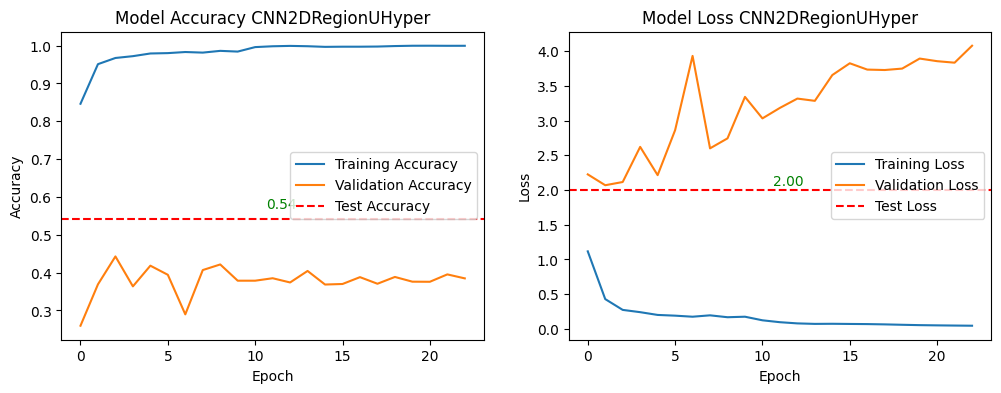

<Figure size 640x480 with 0 Axes>

191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8739 - loss: 0.6937


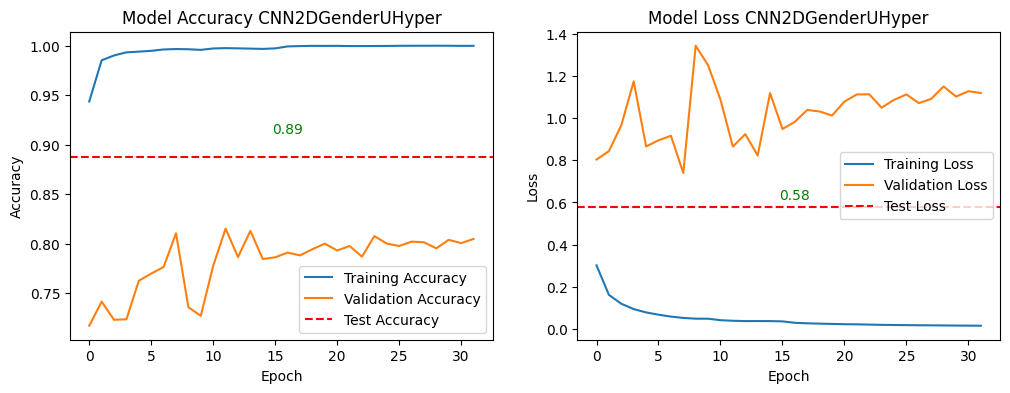

<Figure size 640x480 with 0 Axes>

In [95]:
Evaluateandlogperformance(CNN2DRegionUHyper, historyCNN2DRegionUHyper, Xr_test_2D, yr_test_cat, 'CNN2DRegionUHyper', detail = False)
Evaluateandlogperformance(CNN2DGenderUHyper, historyCNN2DGenderUHyper, Xg_test_2D, yg_test_cat, 'CNN2DGenderUHyper', detail = False)

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


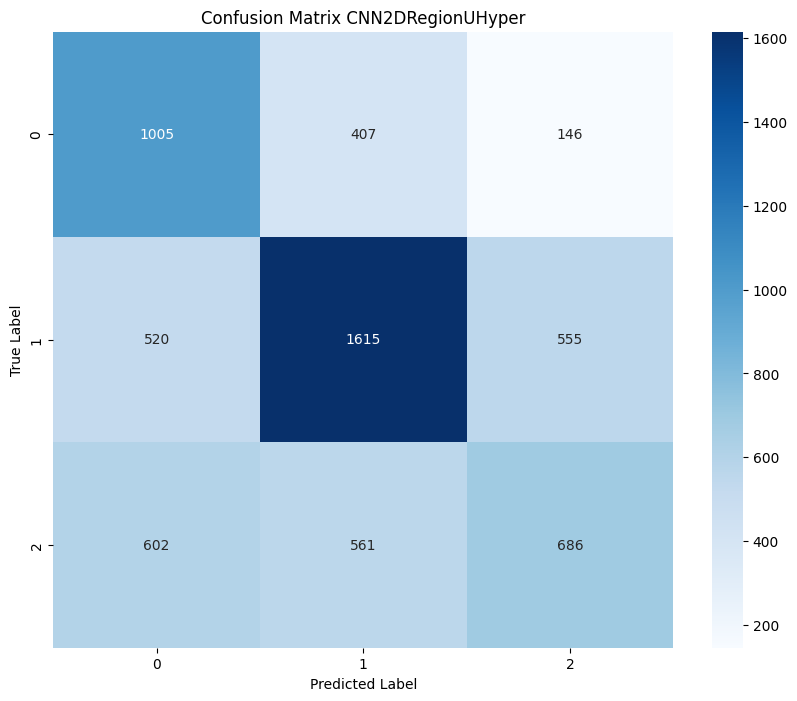


Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.65      0.55      1558
           1       0.63      0.60      0.61      2690
           2       0.49      0.37      0.42      1849

    accuracy                           0.54      6097
   macro avg       0.53      0.54      0.53      6097
weighted avg       0.55      0.54      0.54      6097


Detailed Metrics by Class:

Class 0:
Precision: 0.4725
Recall: 0.6451
F1-score: 0.5455

Class 1:
Precision: 0.6252
Recall: 0.6004
F1-score: 0.6126

Class 2:
Precision: 0.4946
Recall: 0.3710
F1-score: 0.4240

Overall Metrics:
Average Precision: 0.5466
Average Recall: 0.5422
Average F1-score: 0.5382
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


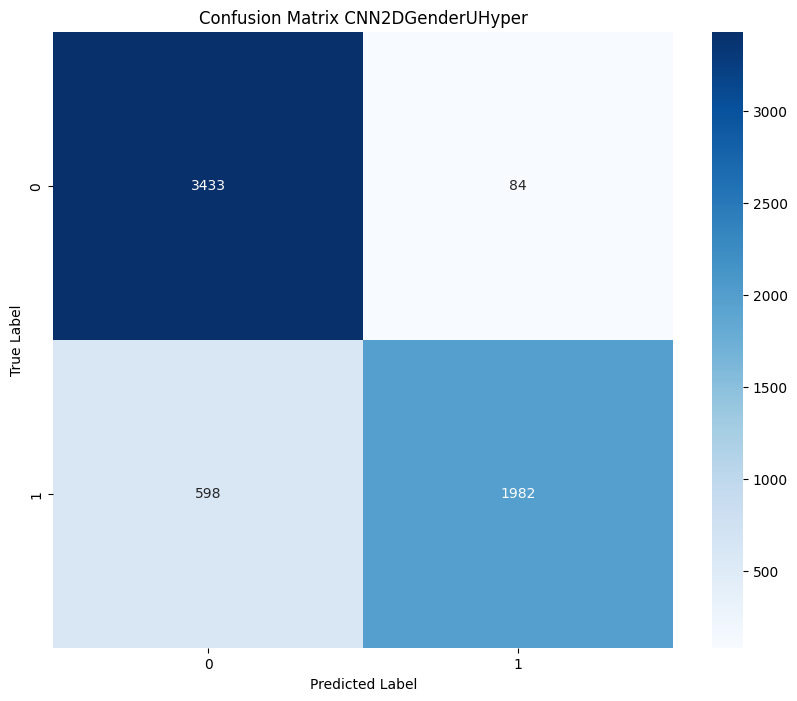


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      3517
           1       0.96      0.77      0.85      2580

    accuracy                           0.89      6097
   macro avg       0.91      0.87      0.88      6097
weighted avg       0.90      0.89      0.89      6097


Detailed Metrics by Class:

Class 0:
Precision: 0.8516
Recall: 0.9761
F1-score: 0.9096

Class 1:
Precision: 0.9593
Recall: 0.7682
F1-score: 0.8532

Overall Metrics:
Average Precision: 0.8972
Average Recall: 0.8881
Average F1-score: 0.8858


In [98]:
compute_confusion_matrix(CNN2DRegionUHyper, Xr_test_2D, yr_test_cat, 'CNN2DRegionUHyper', 3)
compute_confusion_matrix(CNN2DGenderUHyper, Xg_test_2D, yg_test_cat, 'CNN2DGenderUHyper', 2)

In [99]:
CNN2DRegionUHyper.summary()
CNN2DGenderUHyper.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 7, 10, 80)           │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 7, 10, 80)           │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 10, 80)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 10, 32)           │          64,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 7, 10, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 7, 10, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2240)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 80)                  │         179,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 80)                  │             320 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 739,803 (2.82 MB)

 Trainable params: 246,467 (962.76 KB)

 Non-trainable params: 400 (1.56 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 7, 10, 48)           │           1,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 7, 10, 48)           │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 10, 48)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 10, 16)           │           6,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 7, 10, 16)           │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 7, 10, 16)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1120)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 48)                  │          53,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 24)                  │           1,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 190,720 (745.00 KB)

 Trainable params: 63,482 (247.98 KB)

 Non-trainable params: 272 (1.06 KB)

 Optimizer params: 126,966 (495.96 KB)

In [100]:
CNN2DRegionUHyper.save('best_region_recognition_model_update.keras')
CNN2DGenderUHyper.save("best_gender_recognition_model_update.keras")

# Total


## Model